# MobiFall — AFD-CNN 4 s Model: Full-Signal Sliding-Window Scan

Applies the **SisFall 4 s peak/random-balanced model** (`model/sisfall_peak4s_random_balanced_model.ckpt`) to **full MobiFall recordings** (not just the annotated event phase) using a dense sliding window.

For each recording the notebook produces a 3-panel time-series plot:
1. **Signal** — vector magnitude ‖a‖ (g) with annotated phase backgrounds (STD / fall event / LYI) and window class shading.
2. **P(Fall)** — per-window fall probability (blue < 0.5 threshold, red ≥ 0.5).
3. **Fall logit** — raw pre-softmax logit for the Fall class.

**Activities covered:**
- **Falls:** FOL (Forward-lying), FKL (Front-knees-lying), BSC (Back-sitting-chair), SDL (Sideward-lying)
- **ADL reference:** WAL (Walking)

**Preprocessing (same as training):**
- MobiFall accelerometer in m/s² → g (÷ 9.81)
- Resample 200 Hz → 100 Hz
- SisFall ADXL345 normalization: `(g × 256 + 4096) / 8192 × 255` → [0, 255]
- Input: 400 samples × 3 axes = **1200 values, direct (no repeat)**

**Sliding window:** WIN_LEN = 400 samples (4 s), STEP = 25 samples (0.25 s)

## 0. Imports

In [16]:
import os
import sys
import importlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import resample_poly

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC = '/home/ubuntu/git/FD-CNN/src'
if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)
import cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.4


## 1. Constants

In [17]:
ANN_PATH   = 'MobiFall_dataset/Annotated Data'
MODEL_CKPT = 'model/sisfall_peak4s_random_balanced_model.ckpt'

FS_MOBIFALL = 200    # Hz — MobiAct sample rate
FS_CNN      = 100    # Hz — AFD-CNN training rate
WIN_LEN     = 400    # samples at 100 Hz = 4 s
STEP        = 25     # samples at 100 Hz = 0.25 s
BATCH_SIZE  = 512

# Set to an integer to limit plots per code; None = plot all files
MAX_FALL_FILES_PER_CODE = 5
MAX_WALK_FILES          = 5

FALL_CODES = ['FOL', 'FKL', 'BSC', 'SDL']
FALL_DESCRIPTIONS = {
    'FOL': 'Forward-lying',
    'FKL': 'Front-knees-lying',
    'BSC': 'Back-sitting-chair',
    'SDL': 'Sideward-lying',
}
WALK_CODE = 'WAL'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand→Sit', 9: 'Sit→Stand',
}
CLASS_COLORS = {
    0: '#e84040', 2: '#4a8fd4', 3: '#56b56e', 4: '#e09c30',
    5: '#9b6bd4', 6: '#d47bb5', 7: '#888888', 9: '#aaaaaa',
}

# Background colors for annotated phases in the signal panel
PHASE_COLORS = {
    'STD': '#cccccc',   # standing (pre-fall)
    'FOL': '#ffaaaa',   # fall event
    'FKL': '#ffaaaa',
    'BSC': '#ffaaaa',
    'SDL': '#ffaaaa',
    'LYI': '#aaaaff',   # lying (post-fall)
    'WAL': '#aaffaa',   # walking
}

FALL_IDX = CLASS_LIST.index(0)   # index of Fall class in logit/prob vectors

# Activity logits overlaid on the Fall logit panel in every figure
LOGIT_OVERLAY = [(2, 'Walk'), (3, 'Jog'), (4, 'Jump'), (5, 'Up-stairs'), (6, 'Down-stairs'), (7, 'Stand→Sit'), (9, 'Sit→Stand')]

print('Model:', MODEL_CKPT)
print(f'Window: {WIN_LEN} samples @ {FS_CNN} Hz = {WIN_LEN/FS_CNN:.0f} s  →  {WIN_LEN * 3} values (direct, no repeat)')
print(f'Step  : {STEP} samples = {STEP/FS_CNN:.2f} s')
print(f'Logit overlay: Fall + {[n for _, n in LOGIT_OVERLAY]}')

Model: model/sisfall_peak4s_random_balanced_model.ckpt
Window: 400 samples @ 100 Hz = 4 s  →  1200 values (direct, no repeat)
Step  : 25 samples = 0.25 s
Logit overlay: Fall + ['Walk', 'Jog', 'Jump', 'Up-stairs', 'Down-stairs', 'Stand→Sit', 'Sit→Stand']


## 2. Load AFD-CNN 4 s Model

In [18]:
tf.reset_default_graph()
fd_x_ph            = tf.placeholder(tf.float32, [None, 1200], name='fd_input')
fd_logits, fd_keep = cnn_module.fall_net(fd_x_ph)
fd_probs_op        = tf.nn.softmax(fd_logits)

fd_saver = tf.train.Saver()
fd_sess  = tf.Session()
fd_saver.restore(fd_sess, MODEL_CKPT)

print('Model restored from:', MODEL_CKPT)
print('Logit tensor shape :', fd_logits.shape)

Model restored from: model/sisfall_peak4s_random_balanced_model.ckpt
Logit tensor shape : (?, 8)


## 3. Preprocessing Helpers

In [19]:
def load_and_scan(filepath):
    """
    Load a MobiFall annotated CSV, resample to 100 Hz, normalize, and
    extract overlapping 4 s windows across the ENTIRE recording.

    Returns
    -------
    arr_g_100  : (N, 3) float32 — acceleration in g at 100 Hz
    labels_100 : (N,)  str     — phase label per sample at 100 Hz
    windows    : (N_win, 1200) float32 — normalized model inputs
    offsets    : (N_win,) int  — start sample index of each window
    """
    df = pd.read_csv(filepath)
    arr_ms2    = df[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32)
    labels_200 = df['label'].to_numpy(dtype=str) if 'label' in df.columns \
                 else np.full(len(df), '?')

    # m/s² → g, then resample 200 → 100 Hz
    arr_g_100 = resample_poly((arr_ms2 / 9.81).astype(np.float32), 1, 2, axis=0)
    n_out     = len(arr_g_100)

    # Decimate labels (take every other sample, clip to resampled length)
    lab_dec    = labels_200[::2]
    labels_100 = lab_dec[:n_out] if len(lab_dec) >= n_out \
                 else np.pad(lab_dec, (0, n_out - len(lab_dec)), mode='edge')

    # SisFall ADXL345 normalization: (g × 256 + 4096) / 8192 × 255
    arr_norm = np.clip(
        (arr_g_100 * 256.0 + 4096.0) / 8192.0 * 255.0, 0.0, 255.0
    ).astype(np.float32)

    # Sliding window — direct flatten, no repeat
    windows, offsets = [], []
    for off in range(0, n_out - WIN_LEN + 1, STEP):
        windows.append(arr_norm[off: off + WIN_LEN].flatten())  # (1200,)
        offsets.append(off)

    windows_arr = (np.array(windows, dtype=np.float32)
                   if windows else np.empty((0, 1200), dtype=np.float32))
    return arr_g_100, labels_100, windows_arr, np.array(offsets, dtype=int)


def batch_infer(windows_arr):
    """Run model inference on (N, 1200) array.  Returns probs (N, 8) and logits (N, 8)."""
    if len(windows_arr) == 0:
        return np.empty((0, len(CLASS_LIST))), np.empty((0, len(CLASS_LIST)))
    all_p, all_l = [], []
    for s in range(0, len(windows_arr), BATCH_SIZE):
        batch = windows_arr[s: s + BATCH_SIZE]
        l, p  = fd_sess.run([fd_logits, fd_probs_op],
                            feed_dict={fd_x_ph: batch, fd_keep: 1.0})
        all_p.append(p)
        all_l.append(l)
    return np.vstack(all_p), np.vstack(all_l)


def plot_recording(arr_g_100, labels_100, offsets, probs, logits, fname, activity_label):
    """
    3-panel time-series plot for one MobiFall recording:
      Panel 1 — ‖a‖ (g) with phase backgrounds and window class shading
      Panel 2 — P(Fall) per window
      Panel 3 — Fall logit + Walk / Jog / Jump logits per window
    """
    if len(offsets) == 0:
        print(f'  No windows for {fname}, skipping.')
        return

    n          = len(arr_g_100)
    t          = np.arange(n) / FS_CNN                    # seconds
    mag        = np.linalg.norm(arr_g_100, axis=1)        # ‖a‖ in g
    fall_prob  = probs[:, FALL_IDX]
    fall_logit = logits[:, FALL_IDX]
    pred_cls   = [CLASS_LIST[i] for i in np.argmax(probs, axis=1)]
    x_starts   = offsets / FS_CNN                         # window start (s)
    x_centers  = (offsets + WIN_LEN / 2) / FS_CNN         # window centre (s)
    bar_w      = WIN_LEN / FS_CNN                          # 4 s

    fig, (ax_sig, ax_fall, ax_logit) = plt.subplots(
        3, 1, figsize=(14, 6.5), sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
    )

    # ── Signal panel ──────────────────────────────────────────────────────
    phase_legend = {}
    unique_labels = list(dict.fromkeys(labels_100))
    for lbl in unique_labels:
        mask    = labels_100 == lbl
        changes = np.diff(mask.astype(np.int8), prepend=0, append=0)
        color   = PHASE_COLORS.get(lbl, '#eeeeee')
        for si, ei in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
            ax_sig.axvspan(t[si], t[min(ei, n - 1)],
                           color=color, alpha=0.30, linewidth=0)
        phase_legend[lbl] = color

    for xs, pc in zip(x_starts, pred_cls):
        ax_sig.axvspan(xs, xs + bar_w,
                       color=CLASS_COLORS.get(pc, '#cccccc'), alpha=0.13, linewidth=0)

    ax_sig.plot(t, mag, color='black', lw=0.5, alpha=0.85)
    ax_sig.set_ylabel('‖a‖ (g)', fontsize=9)
    ax_sig.set_title(
        f'{activity_label} | {fname}  —  {len(offsets)} windows  '
        f'(fall alerts: {(fall_prob >= 0.5).sum()} / {len(offsets)})',
        fontsize=10,
    )

    phase_patches = [mpatches.Patch(color=phase_legend[l], alpha=0.5, label=l)
                     for l in unique_labels]
    class_patches = [mpatches.Patch(color=CLASS_COLORS[l], alpha=0.5,
                                    label=CLASS_NAMES[l]) for l in CLASS_LIST]
    ax_sig.legend(handles=phase_patches + class_patches,
                  fontsize=7, loc='upper right',
                  ncol=min(4, len(phase_patches) + len(class_patches)),
                  framealpha=0.85)

    # ── P(Fall) panel ─────────────────────────────────────────────────────
    ax_fall.fill_between(x_centers, 0, fall_prob,
                         where=fall_prob >= 0.5,
                         color='#e84040', alpha=0.75, step='mid', label='P(Fall) ≥ 0.5')
    ax_fall.fill_between(x_centers, 0, fall_prob,
                         where=fall_prob < 0.5,
                         color='#4a8fd4', alpha=0.55, step='mid', label='P(Fall) < 0.5')
    ax_fall.plot(x_centers, fall_prob, color='#111111', lw=0.4, alpha=0.6)
    ax_fall.axhline(0.5, color='red',    ls='--', lw=0.9, label='0.5 threshold')
    ax_fall.axhline(0.3, color='orange', ls=':',  lw=0.8, label='0.3 threshold')
    ax_fall.set_ylim(0, 1.05)
    ax_fall.set_ylabel('P(Fall)', fontsize=9)
    ax_fall.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.85)
    ax_fall.grid(True, axis='y', alpha=0.2)

    # ── Activity logits panel ─────────────────────────────────────────────
    # Fall logit: shaded fill as background, bold line on top
    ax_logit.fill_between(x_centers, 0, fall_logit,
                          where=fall_logit >= 0,
                          color='#e84040', alpha=0.20, step='mid')
    ax_logit.fill_between(x_centers, 0, fall_logit,
                          where=fall_logit < 0,
                          color='#4a8fd4', alpha=0.15, step='mid')
    ax_logit.plot(x_centers, fall_logit,
                  color=CLASS_COLORS[0], lw=1.4, alpha=0.95, label='Fall')
    # Walk, Jog, Jump logits overlaid as coloured lines
    for cls_id, cls_name in LOGIT_OVERLAY:
        ax_logit.plot(x_centers, logits[:, CLASS_LIST.index(cls_id)],
                      color=CLASS_COLORS[cls_id], lw=0.9, alpha=0.85, label=cls_name)
    ax_logit.axhline(0, color='0.25', ls='--', lw=0.9)
    ax_logit.set_ylabel('Logit', fontsize=9)
    ax_logit.set_xlabel('Seconds elapsed', fontsize=9)
    ax_logit.legend(fontsize=7, loc='upper right', ncol=4, framealpha=0.85)
    ax_logit.grid(True, axis='y', alpha=0.2)

    ax_sig.set_xlim(0, t[-1])
    fig.suptitle(
        f'AFD-CNN 4 s model — {activity_label} | {fname}',
        fontsize=12, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


## 4. Fall Recordings — Full-Signal Scan

Each fall recording spans three annotated phases:
- **STD** (standing, pre-fall) — grey background
- **fall code** (e.g., FOL) — pink/red background
- **LYI** (lying, post-fall) — blue background

The sliding window covers all three phases so we can observe P(Fall) rising into the fall event and settling in the lying phase.

In [20]:
# ── Stage 1: load, slide, collect windows per recording ───────────────────
fall_records = []   # list of dicts — one entry per file

for code in FALL_CODES:
    code_dir = os.path.join(ANN_PATH, code)
    files    = sorted(f for f in os.listdir(code_dir) if f.endswith('.csv'))
    print(f'{code} ({FALL_DESCRIPTIONS[code]}): {len(files)} files total')

    for fname in files:
        arr_g, labels, windows, offsets = load_and_scan(
            os.path.join(code_dir, fname)
        )
        fall_records.append(dict(
            code=code, fname=fname,
            arr_g=arr_g, labels=labels,
            windows=windows, offsets=offsets,
        ))

print(f'\nTotal fall recordings loaded: {len(fall_records)}')
total_fall_wins = sum(len(r['windows']) for r in fall_records)
print(f'Total windows to infer    : {total_fall_wins:,}')

FOL (Forward-lying): 192 files total


FKL (Front-knees-lying): 192 files total
BSC (Back-sitting-chair): 191 files total
SDL (Sideward-lying): 192 files total

Total fall recordings loaded: 767
Total windows to infer    : 17,966


In [21]:
# ── Stage 2: batch inference (all fall recordings at once) ────────────────
if total_fall_wins > 0:
    all_fall_wins = np.vstack([r['windows'] for r in fall_records
                               if len(r['windows']) > 0])
    fall_probs_all, fall_logits_all = batch_infer(all_fall_wins)

    # Distribute results back to each recording
    ptr = 0
    for r in fall_records:
        n = len(r['windows'])
        r['probs']  = fall_probs_all[ptr: ptr + n]
        r['logits'] = fall_logits_all[ptr: ptr + n]
        ptr += n

    print(f'Inference done: {len(fall_probs_all):,} windows')
else:
    print('No windows found.')

Inference done: 17,966 windows


In [22]:
# ── Stage 3: per-recording summary table ─────────────────────────────────
summary_rows = []
for r in fall_records:
    if len(r.get('probs', [])) == 0:
        continue
    fp   = r['probs'][:, FALL_IDX]
    fl   = r['logits'][:, FALL_IDX]

    # Windows whose centre falls within the annotated fall-event phase
    centers_i = np.clip(r['offsets'] + WIN_LEN // 2, 0, len(r['labels']) - 1)
    in_event  = r['labels'][centers_i] == r['code']

    summary_rows.append({
        'Code':            r['code'],
        'File':            r['fname'],
        'N windows':       len(fp),
        'Fall alerts':     int((fp >= 0.5).sum()),
        'Alert rate':      float((fp >= 0.5).mean()),
        'In-event wins':   int(in_event.sum()),
        'In-event alerts': int((fp[in_event] >= 0.5).sum()),
        'Mean P(Fall)':    float(fp.mean()),
        'Max P(Fall)':     float(fp.max()),
        'Mean logit':      float(fl.mean()),
        'Max logit':       float(fl.max()),
    })

summary_df = pd.DataFrame(summary_rows)

print('=== Fall recording summary (all files) ===')
print(summary_df.groupby('Code').agg(
    files=('File', 'count'),
    total_wins=('N windows', 'sum'),
    total_alerts=('Fall alerts', 'sum'),
    mean_alert_rate=('Alert rate', 'mean'),
    mean_in_event_alerts=('In-event alerts', 'mean'),
    mean_max_pfail=('Max P(Fall)', 'mean'),
).round(3).to_string())

print()
display(summary_df.style
    .format({
        'Alert rate':      '{:.2%}',
        'Mean P(Fall)':    '{:.3f}',
        'Max P(Fall)':     '{:.3f}',
        'Mean logit':      '{:.2f}',
        'Max logit':       '{:.2f}',
    })
    .background_gradient(subset=['Max P(Fall)', 'Alert rate'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption('Fall recordings — AFD-CNN 4 s model full-signal scan')
)

=== Fall recording summary (all files) ===
      files  total_wins  total_alerts  mean_alert_rate  mean_in_event_alerts  mean_max_pfail
Code                                                                                        
BSC     191        4484          2656            0.593                 5.120           0.909
FKL     192        4508          3863            0.856                 4.781           0.974
FOL     192        4488          4186            0.933                 4.651           1.000
SDL     192        4486          4251            0.947                 5.042           0.995



,Code,File,N windows,Fall alerts,Alert rate,In-event wins,In-event alerts,Mean P(Fall),Max P(Fall),Mean logit,Max logit
0,FOL,FOL_10_1_annotated.csv,24,24,100.00%,9,9,1.000,1.000,61.01,87.63
1,FOL,FOL_10_2_annotated.csv,24,24,100.00%,9,9,1.000,1.000,57.58,78.56
2,FOL,FOL_10_3_annotated.csv,24,24,100.00%,8,8,1.000,1.000,56.61,77.73
3,FOL,FOL_11_1_annotated.csv,24,24,100.00%,7,7,1.000,1.000,25.15,78.20
4,FOL,FOL_11_2_annotated.csv,24,23,95.83%,7,7,0.938,1.000,22.01,66.13
5,FOL,FOL_11_3_annotated.csv,24,24,100.00%,7,7,0.996,1.000,25.88,68.63
6,FOL,FOL_12_1_annotated.csv,24,24,100.00%,4,4,1.000,1.000,32.10,68.41
7,FOL,FOL_12_2_annotated.csv,24,24,100.00%,4,4,1.000,1.000,36.96,54.47
8,FOL,FOL_12_3_annotated.csv,24,24,100.00%,4,4,1.000,1.000,53.45,65.97
9,FOL,FOL_13_1_annotated.csv,24,24,100.00%,7,7,1.000,1.000,37.89,70.79



=== FOL (Forward-lying) — plotting 5 of 192 recordings ===


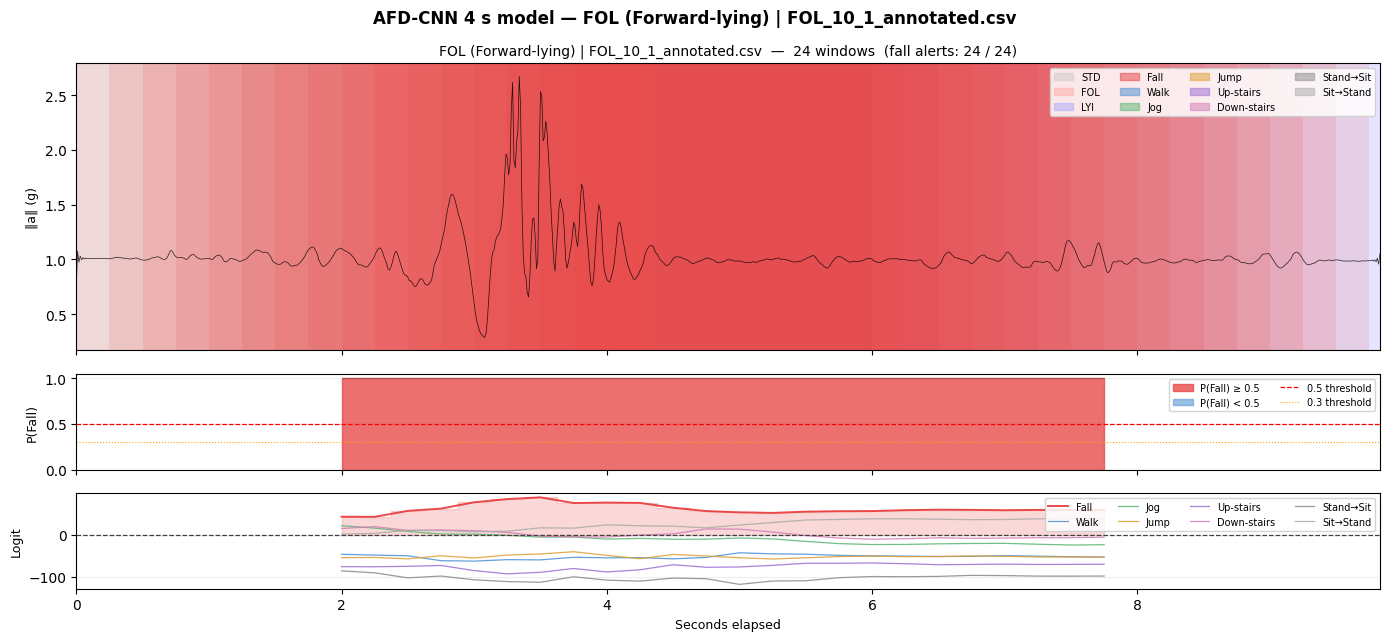

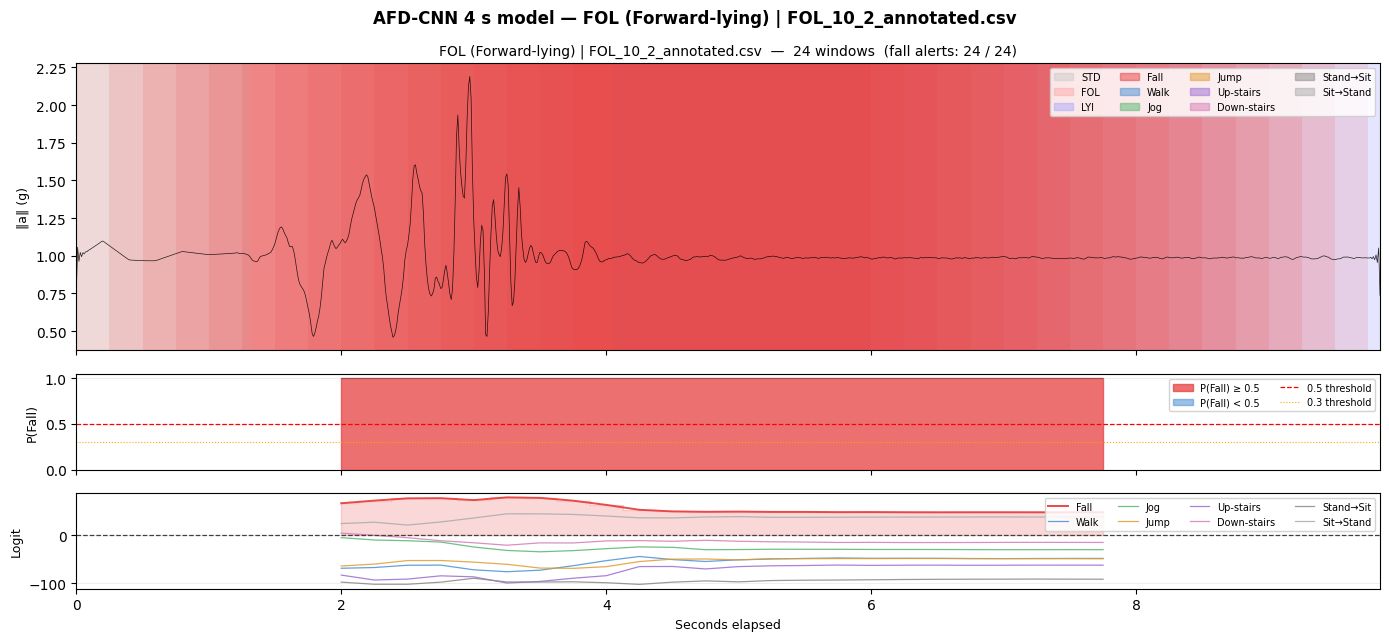

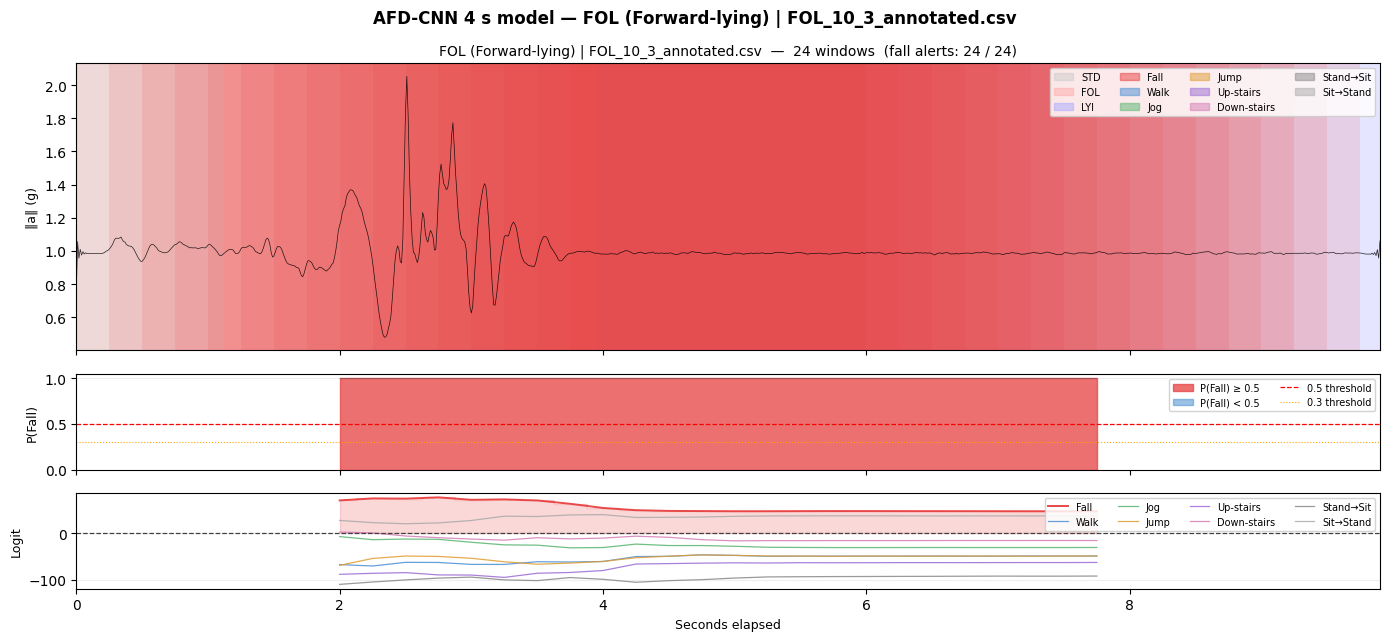

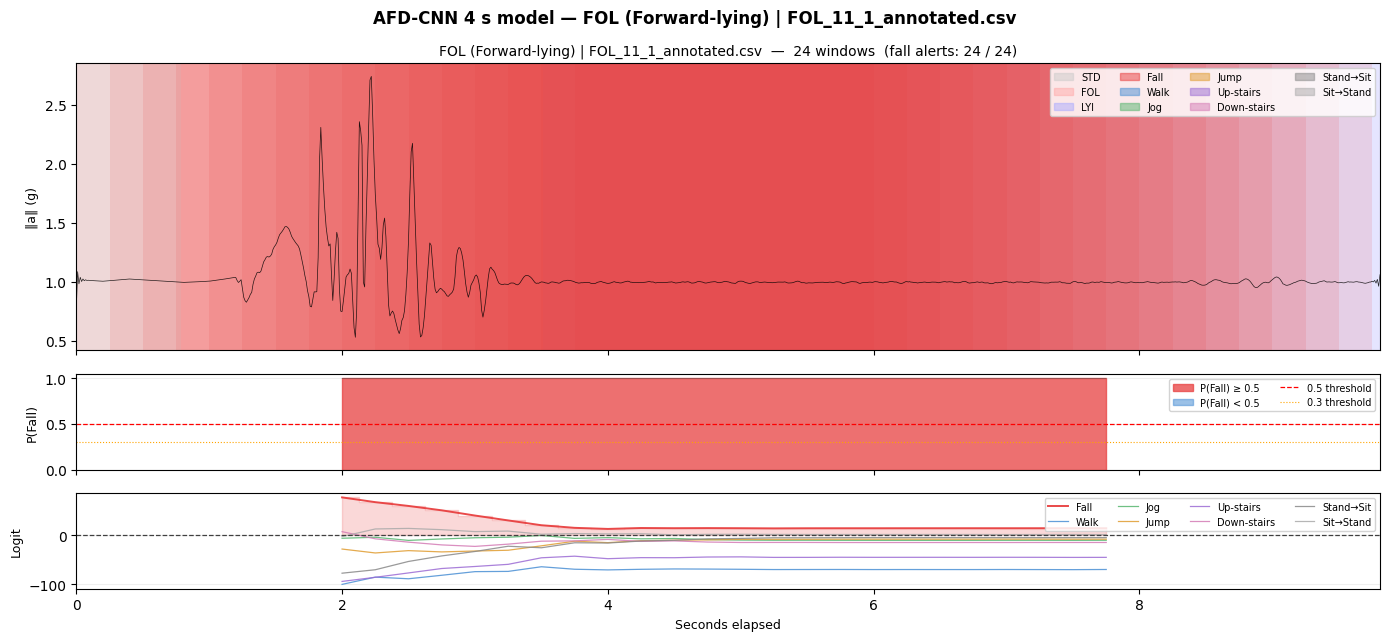

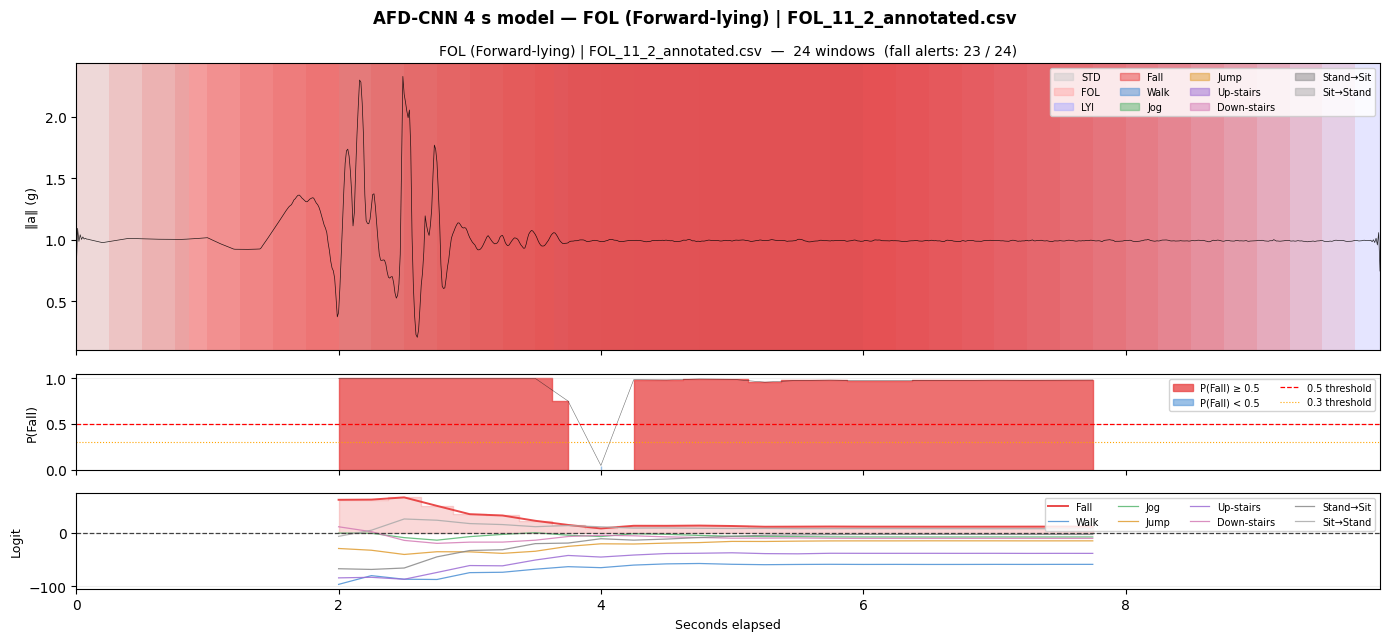


=== FKL (Front-knees-lying) — plotting 5 of 192 recordings ===


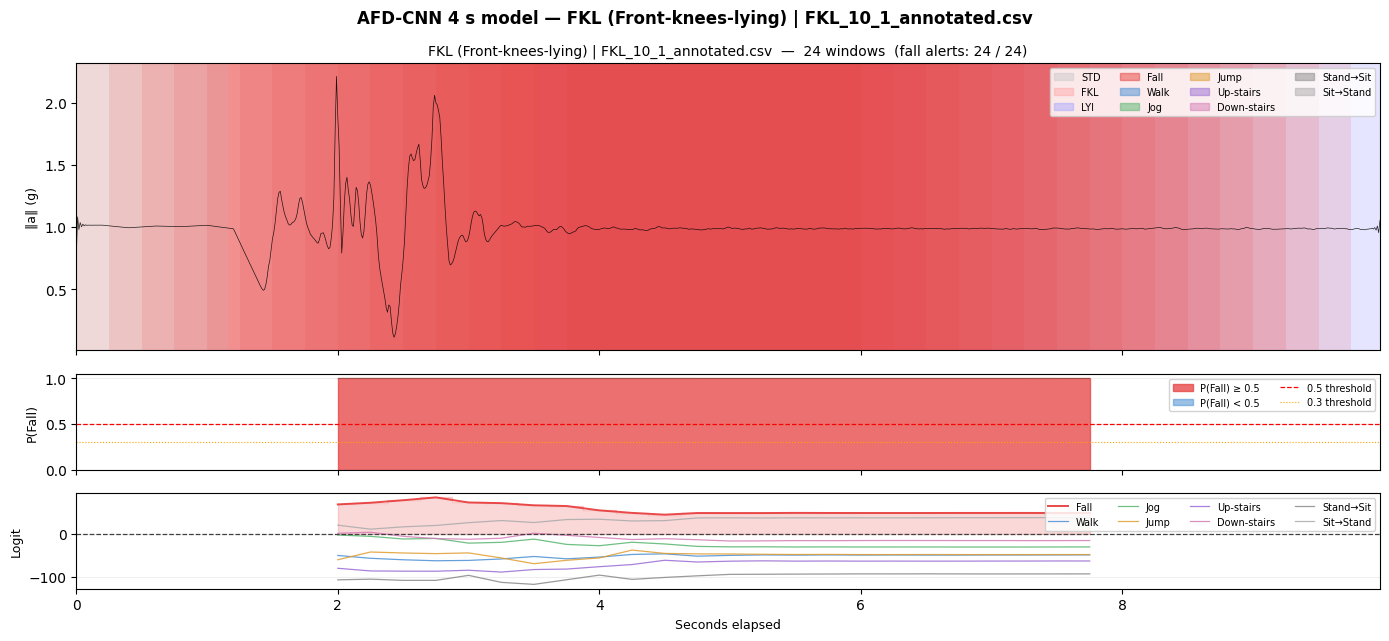

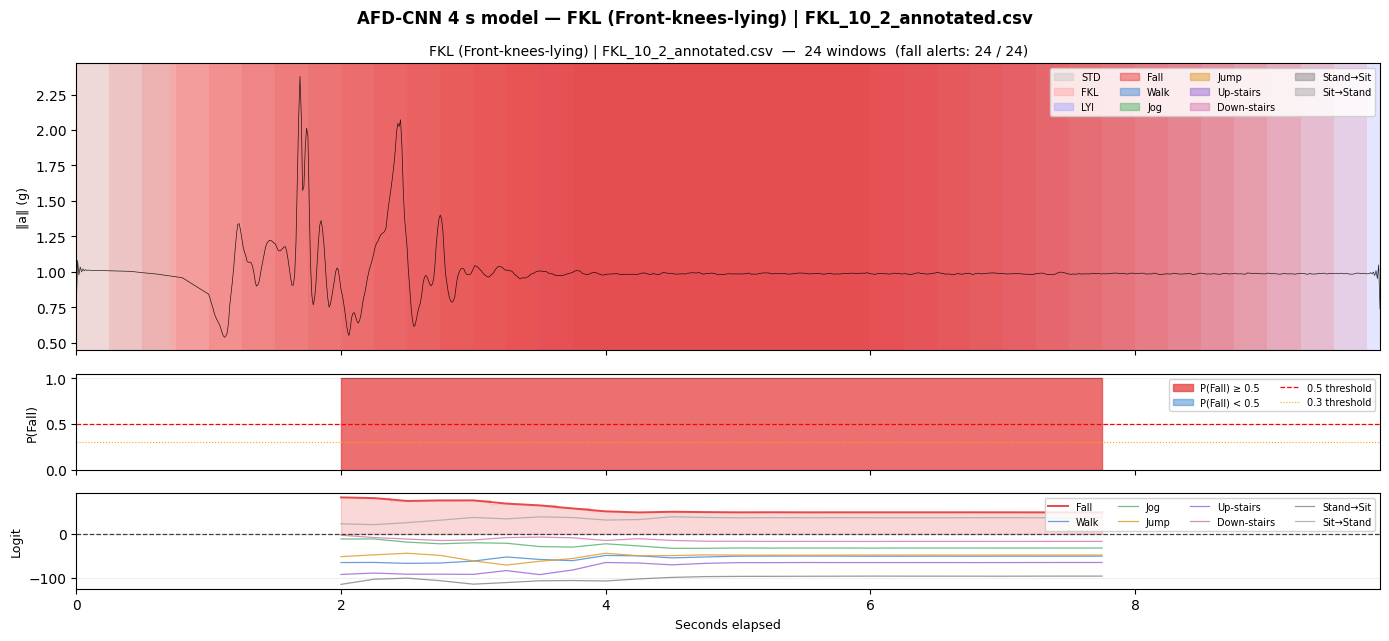

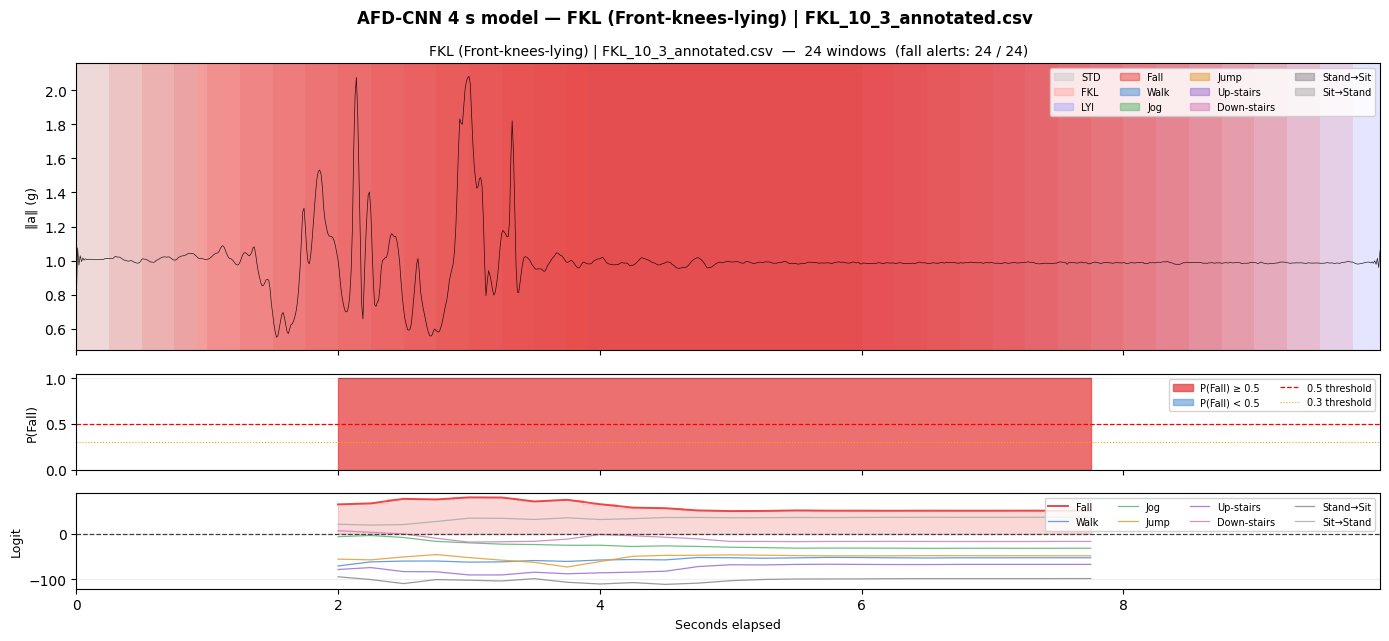

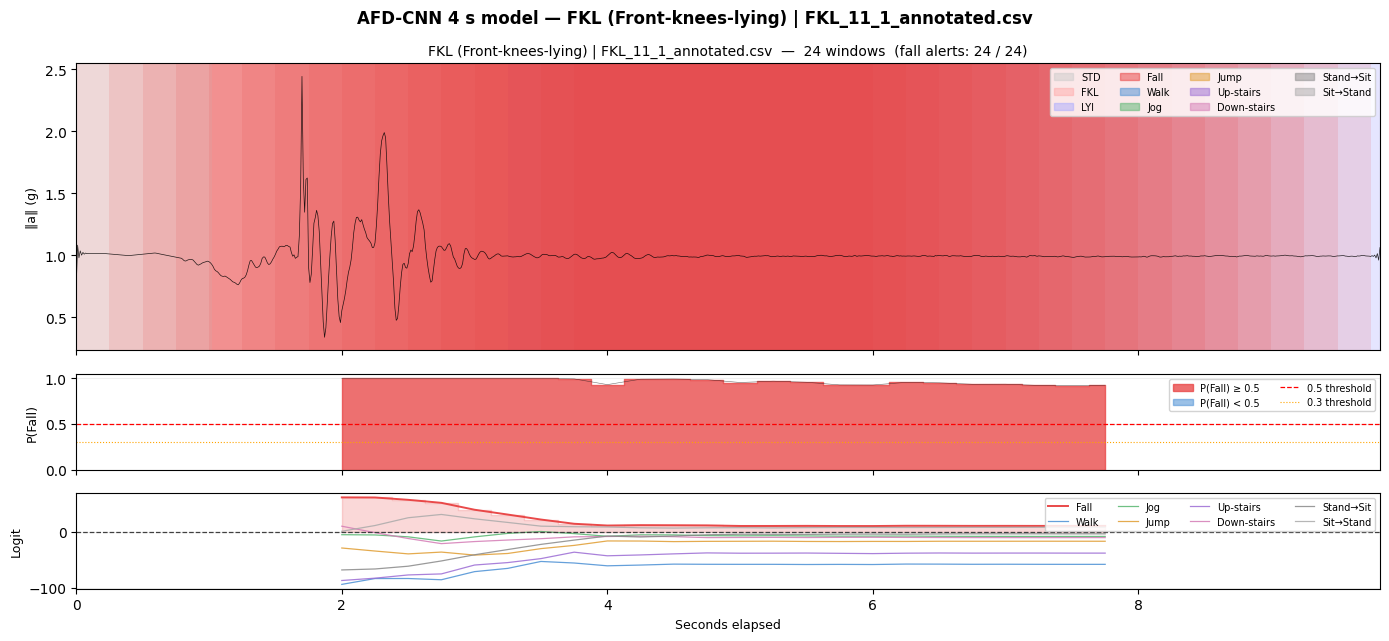

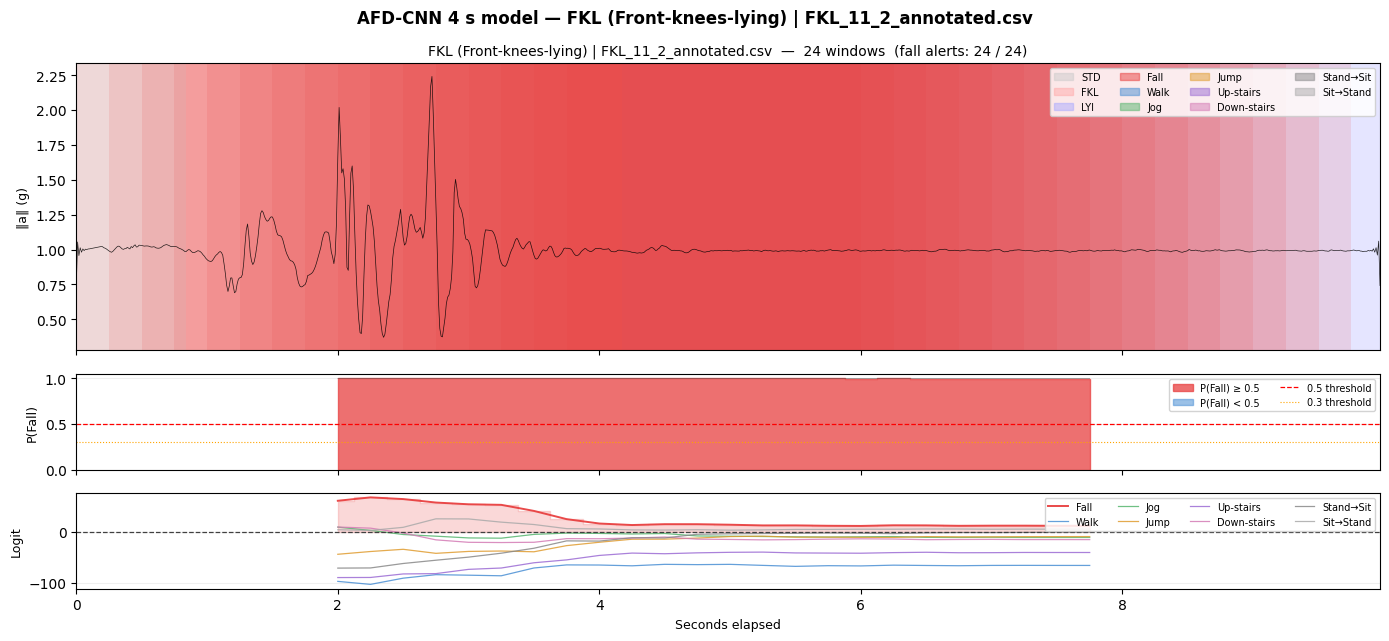


=== BSC (Back-sitting-chair) — plotting 5 of 191 recordings ===


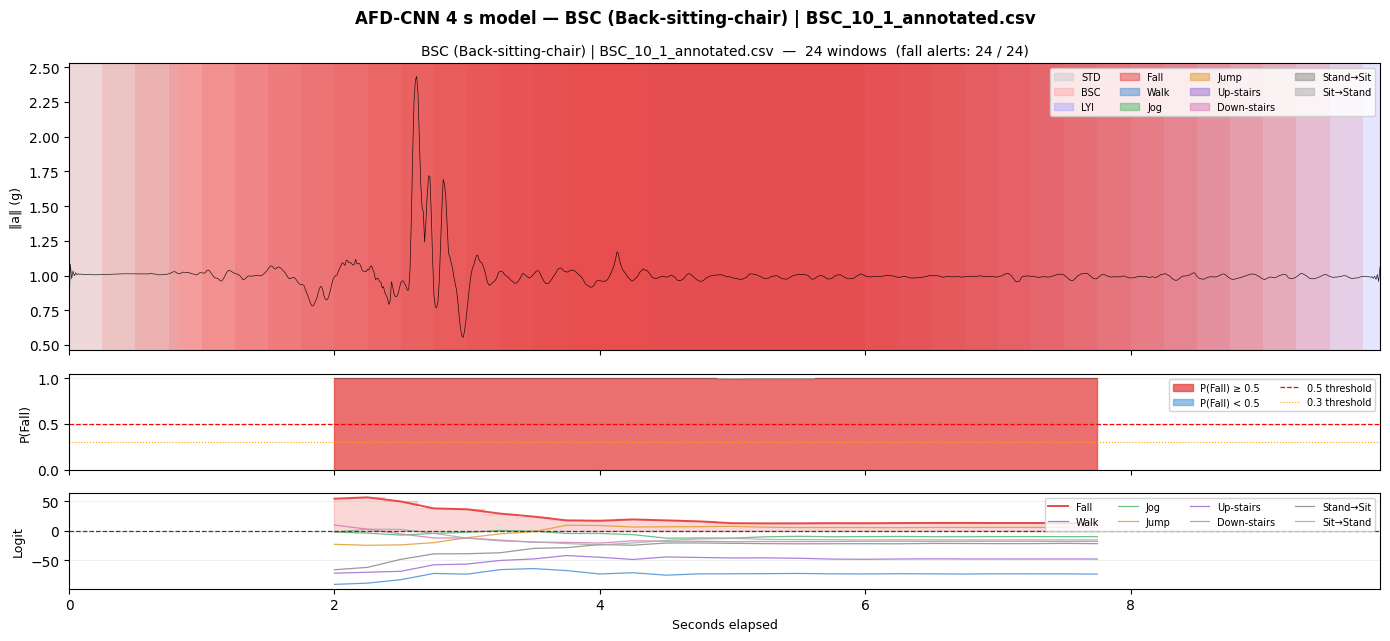

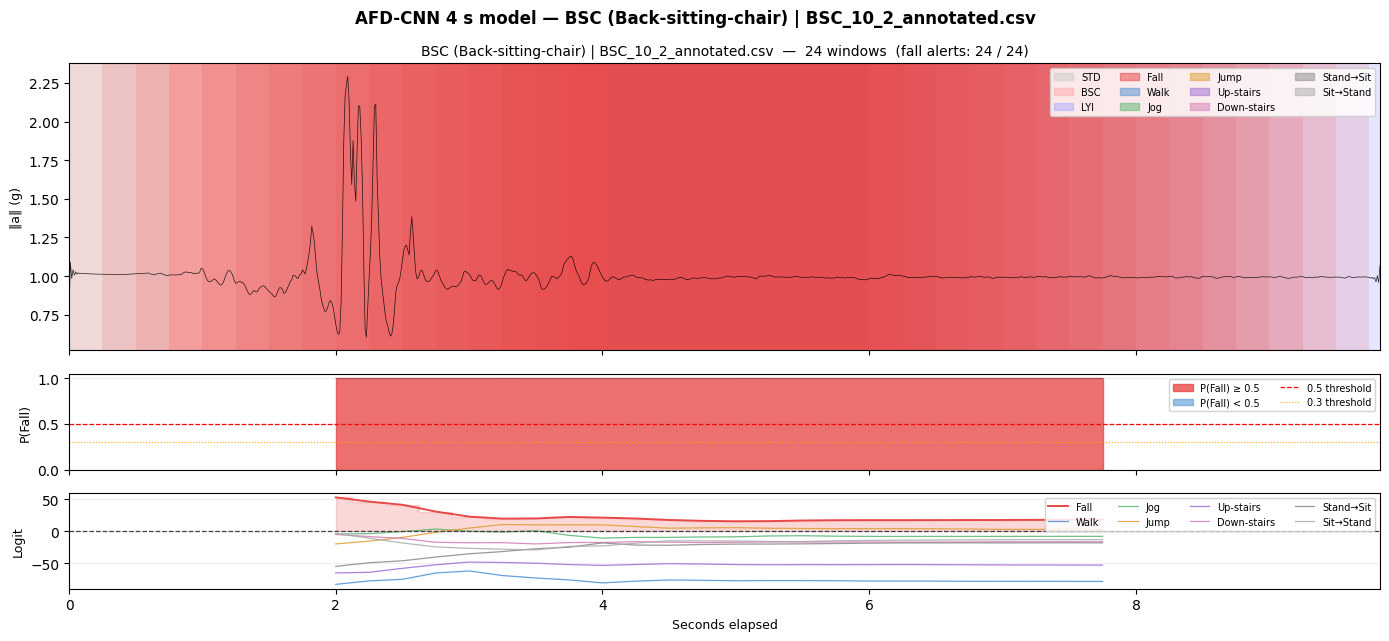

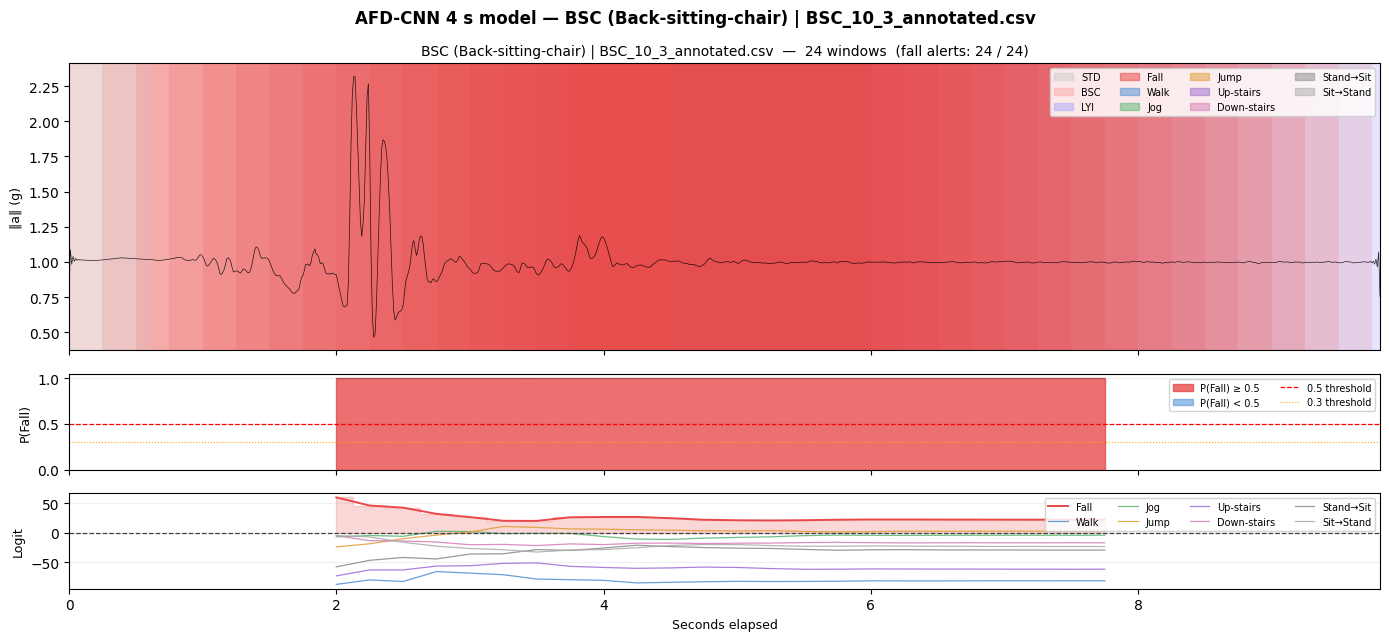

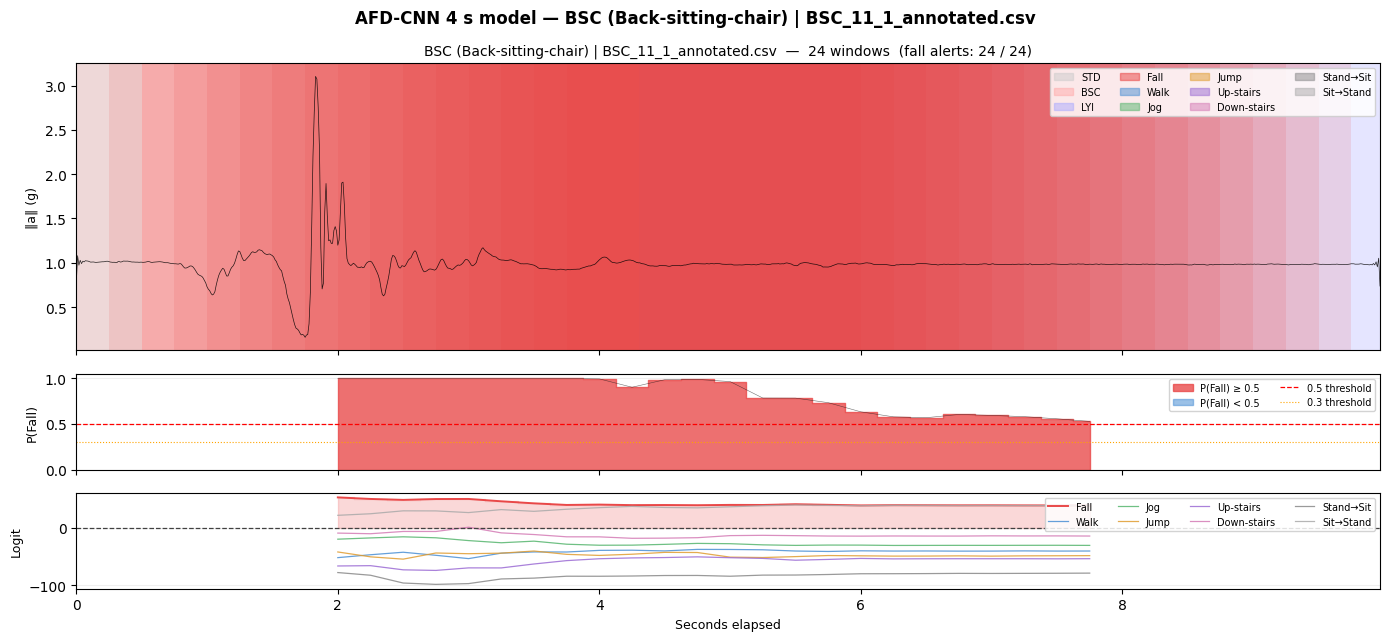

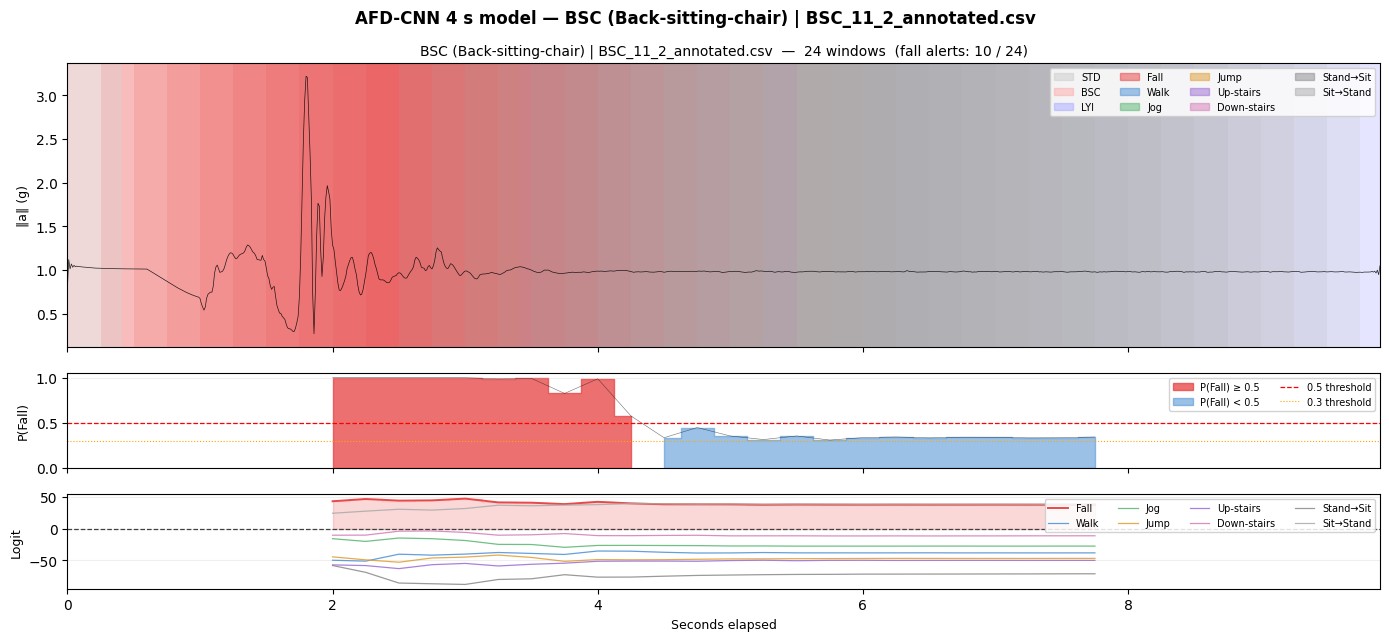


=== SDL (Sideward-lying) — plotting 5 of 192 recordings ===


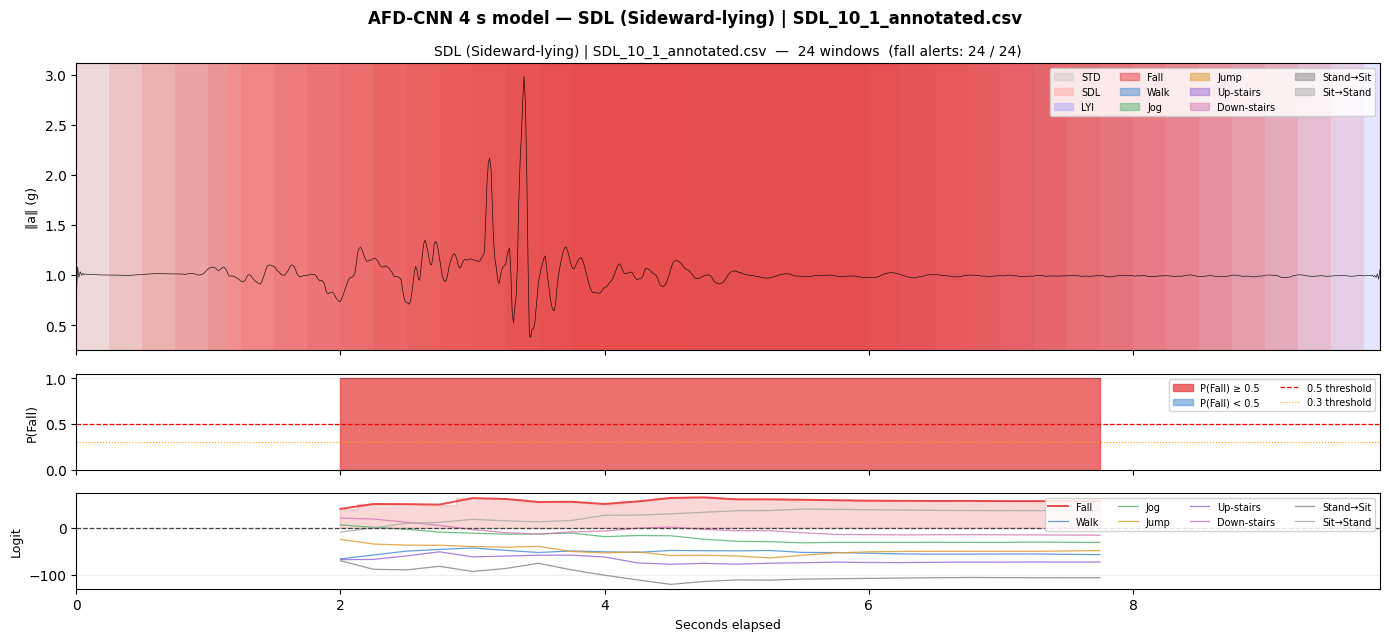

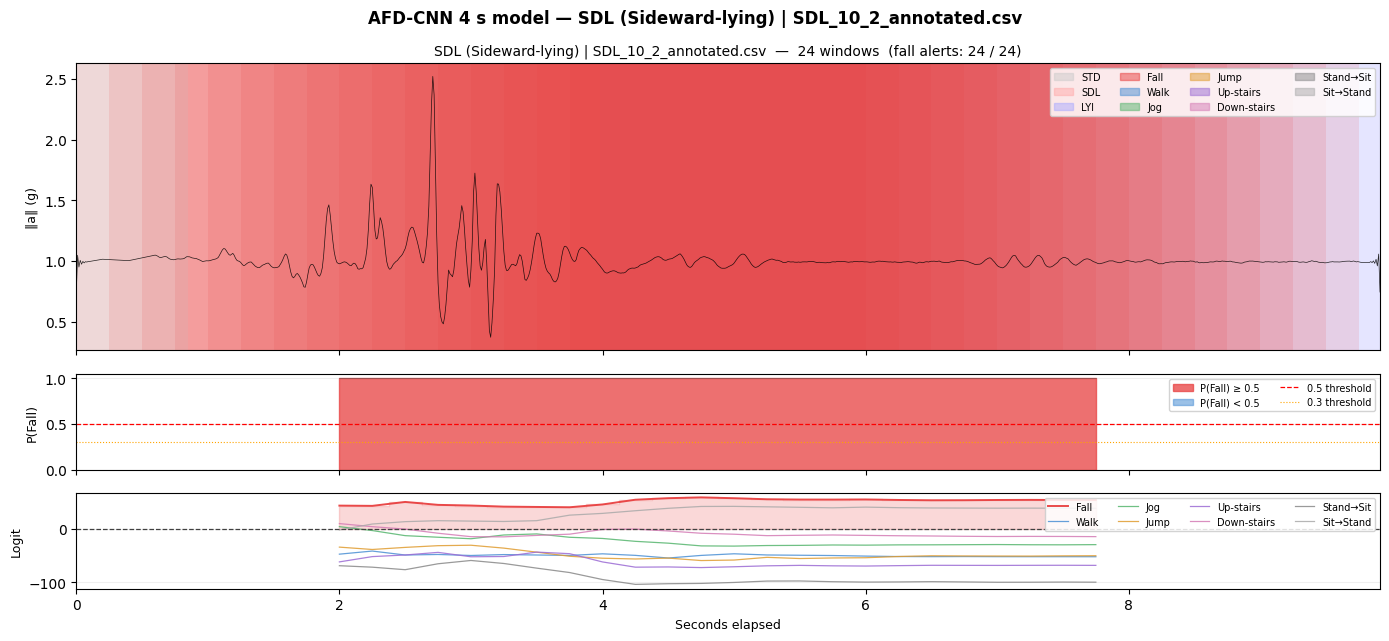

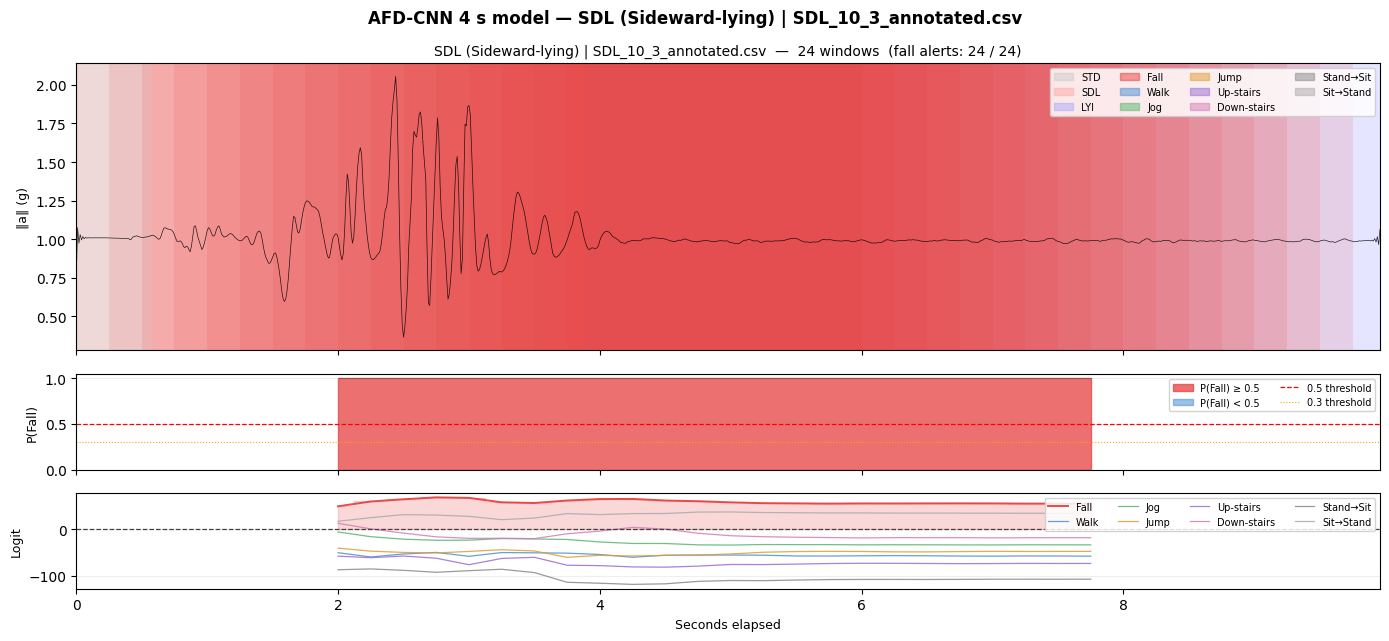

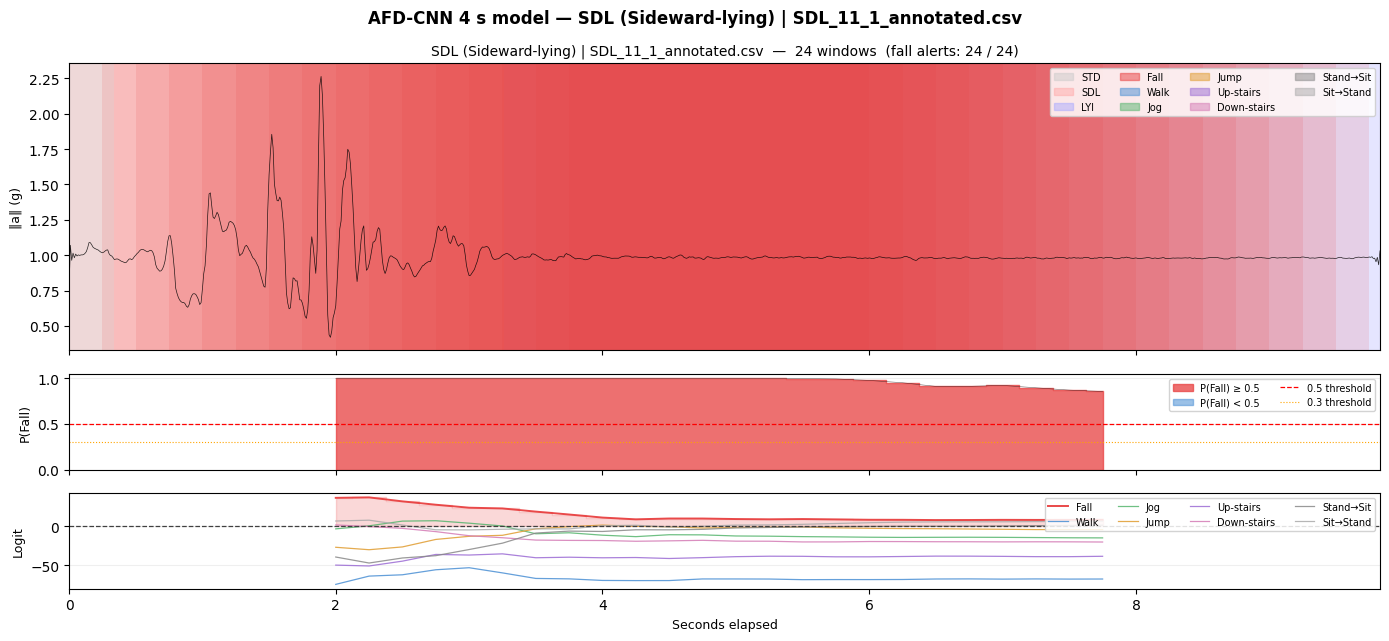

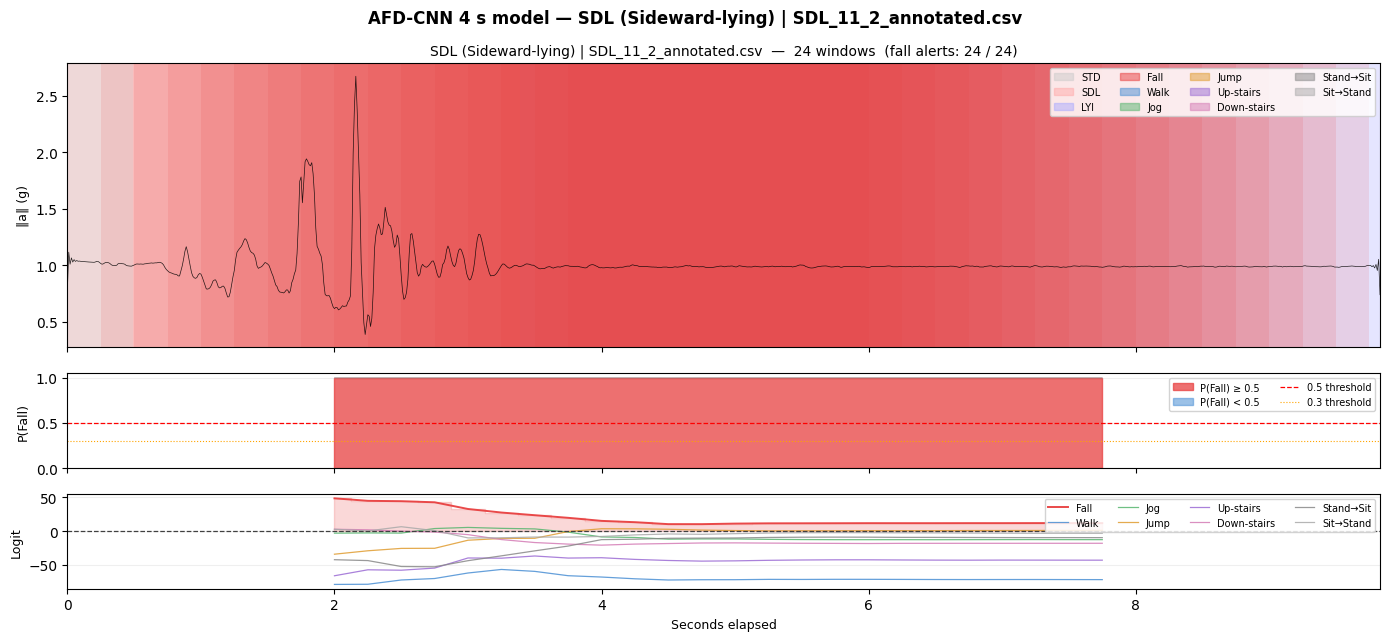

In [23]:
# ── Stage 4: per-recording plots ──────────────────────────────────────────
for code in FALL_CODES:
    recs = [r for r in fall_records if r['code'] == code and len(r.get('probs', [])) > 0]
    to_plot = recs if MAX_FALL_FILES_PER_CODE is None else recs[:MAX_FALL_FILES_PER_CODE]
    print(f'\n=== {code} ({FALL_DESCRIPTIONS[code]}) '
          f'— plotting {len(to_plot)} of {len(recs)} recordings ===')

    for r in to_plot:
        plot_recording(
            r['arr_g'], r['labels'], r['offsets'],
            r['probs'], r['logits'],
            r['fname'],
            f"{r['code']} ({FALL_DESCRIPTIONS[r['code']]})",
        )

## 5. Walk Recordings — Full-Signal Scan

WAL recordings provide a reference ADL baseline.  We expect P(Fall) to stay low throughout, and fall alerts to be rare.

In [24]:
# ── Stage 1: load, slide, collect windows ─────────────────────────────────
walk_records = []

walk_dir = os.path.join(ANN_PATH, WALK_CODE)
walk_files = sorted(f for f in os.listdir(walk_dir) if f.endswith('.csv'))
print(f'{WALK_CODE} (Walking): {len(walk_files)} files total')

for fname in walk_files:
    arr_g, labels, windows, offsets = load_and_scan(
        os.path.join(walk_dir, fname)
    )
    walk_records.append(dict(
        fname=fname,
        arr_g=arr_g, labels=labels,
        windows=windows, offsets=offsets,
    ))

total_walk_wins = sum(len(r['windows']) for r in walk_records)
print(f'Total windows to infer: {total_walk_wins:,}')

WAL (Walking): 61 files total


Total windows to infer: 72,061


In [25]:
# ── Stage 2: batch inference ───────────────────────────────────────────────
if total_walk_wins > 0:
    all_walk_wins = np.vstack([r['windows'] for r in walk_records
                               if len(r['windows']) > 0])
    walk_probs_all, walk_logits_all = batch_infer(all_walk_wins)

    ptr = 0
    for r in walk_records:
        n = len(r['windows'])
        r['probs']  = walk_probs_all[ptr: ptr + n]
        r['logits'] = walk_logits_all[ptr: ptr + n]
        ptr += n

    print(f'Inference done: {len(walk_probs_all):,} windows')
else:
    print('No windows found.')

Inference done: 72,061 windows


In [26]:
# ── Stage 3: summary table ─────────────────────────────────────────────────
walk_summary_rows = []
for r in walk_records:
    if len(r.get('probs', [])) == 0:
        continue
    fp = r['probs'][:, FALL_IDX]
    fl = r['logits'][:, FALL_IDX]
    walk_summary_rows.append({
        'File':          r['fname'],
        'N windows':     len(fp),
        'Fall alerts':   int((fp >= 0.5).sum()),
        'Alert rate':    float((fp >= 0.5).mean()),
        'Mean P(Fall)':  float(fp.mean()),
        'Max P(Fall)':   float(fp.max()),
        'Mean logit':    float(fl.mean()),
        'Max logit':     float(fl.max()),
    })

walk_summary_df = pd.DataFrame(walk_summary_rows)

print('=== Walk recording summary (all files) ===')
print(f"  Total files          : {len(walk_summary_df)}")
print(f"  Total windows        : {walk_summary_df['N windows'].sum():,}")
print(f"  Total fall alerts    : {walk_summary_df['Fall alerts'].sum():,}")
print(f"  Mean alert rate      : {walk_summary_df['Alert rate'].mean():.3f}")
print(f"  Mean max P(Fall)     : {walk_summary_df['Max P(Fall)'].mean():.3f}")
print()
display(walk_summary_df.style
    .format({
        'Alert rate':   '{:.2%}',
        'Mean P(Fall)': '{:.3f}',
        'Max P(Fall)':  '{:.3f}',
        'Mean logit':   '{:.2f}',
        'Max logit':    '{:.2f}',
    })
    .background_gradient(subset=['Max P(Fall)', 'Alert rate'], cmap='RdYlGn_r', vmin=0, vmax=1)
    .set_caption('Walk recordings — AFD-CNN 4 s model full-signal scan')
)

=== Walk recording summary (all files) ===
  Total files          : 61
  Total windows        : 72,061
  Total fall alerts    : 65,354
  Mean alert rate      : 0.907
  Mean max P(Fall)     : 0.919



,File,N windows,Fall alerts,Alert rate,Mean P(Fall),Max P(Fall),Mean logit,Max logit
0,WAL_10_1_annotated.csv,1184,1184,100.00%,1.000,1.000,49.65,66.69
1,WAL_11_1_annotated.csv,1184,1184,100.00%,1.000,1.000,53.13,66.18
2,WAL_12_1_annotated.csv,1181,1180,99.92%,0.998,1.000,43.79,64.85
3,WAL_16_1_annotated.csv,1182,1182,100.00%,1.000,1.000,68.41,81.78
4,WAL_18_1_annotated.csv,1182,1182,100.00%,1.000,1.000,66.51,78.51
5,WAL_19_1_annotated.csv,1180,1180,100.00%,1.000,1.000,50.86,65.22
6,WAL_1_1_annotated.csv,1180,1180,100.00%,1.000,1.000,47.05,69.83
7,WAL_20_1_annotated.csv,1179,1179,100.00%,1.000,1.000,38.96,61.98
8,WAL_21_1_annotated.csv,1178,0,0.00%,0.000,0.001,-8.14,-4.40
9,WAL_22_1_annotated.csv,1181,1181,100.00%,1.000,1.000,49.45,60.41


Plotting 5 of 61 WAL recordings...


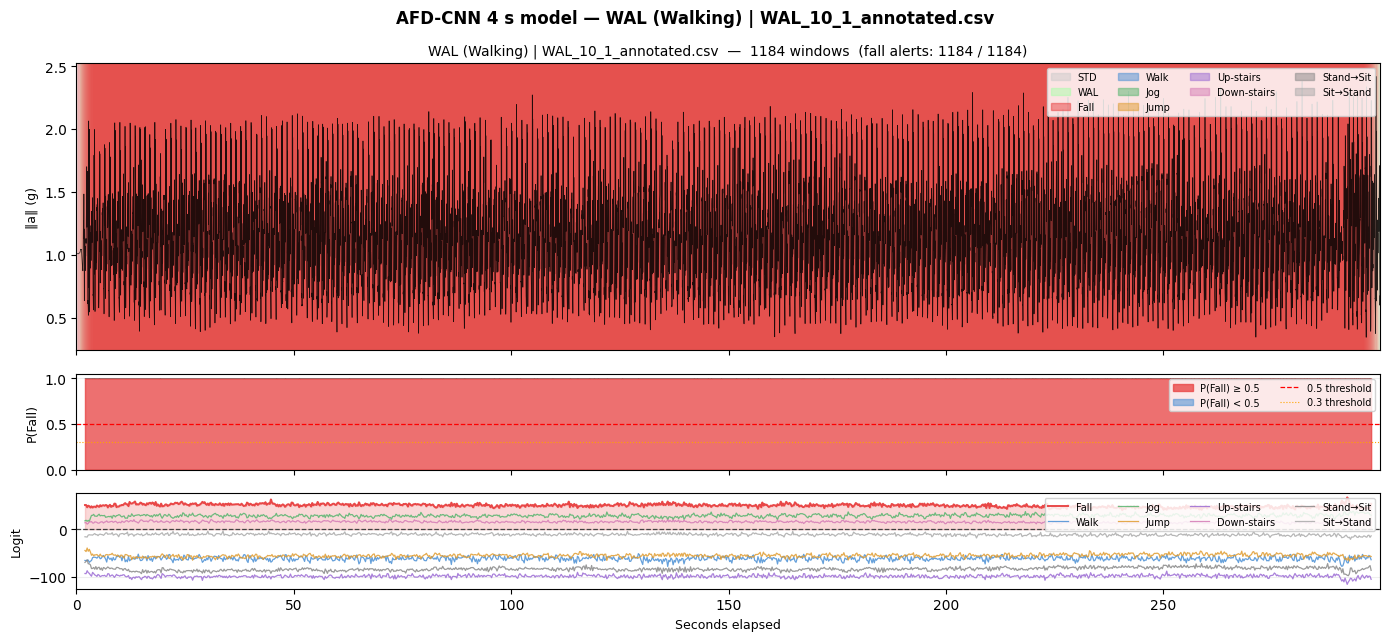

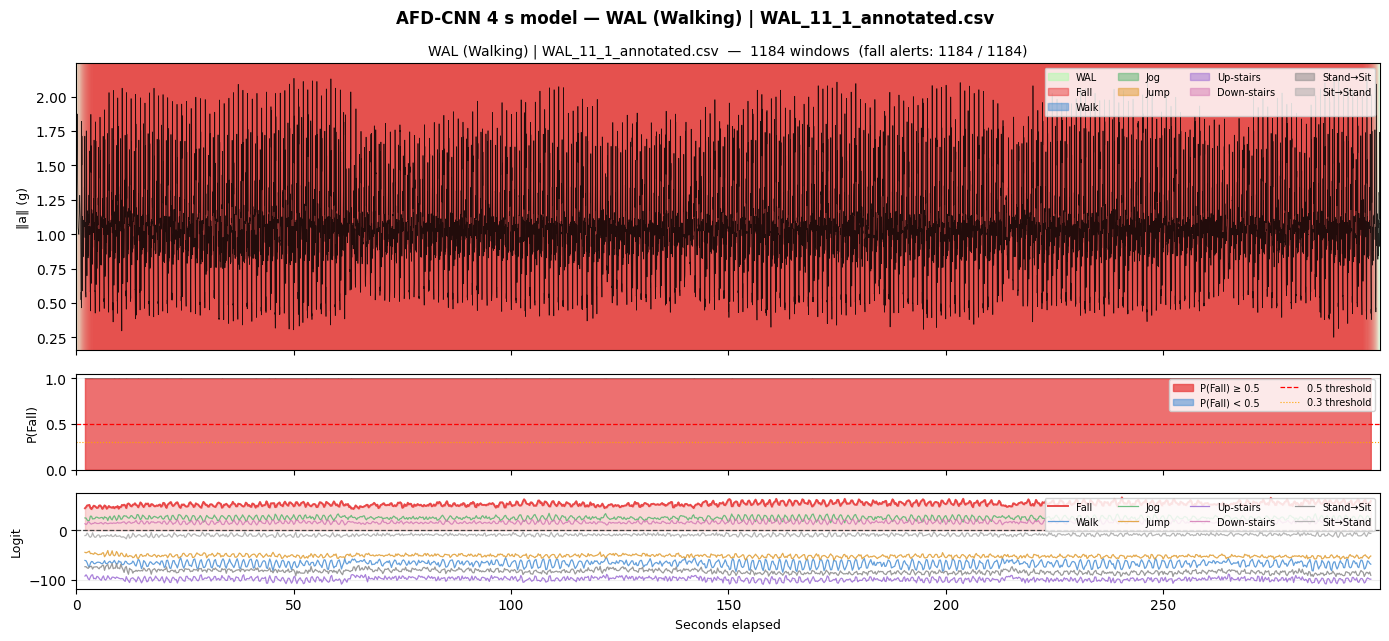

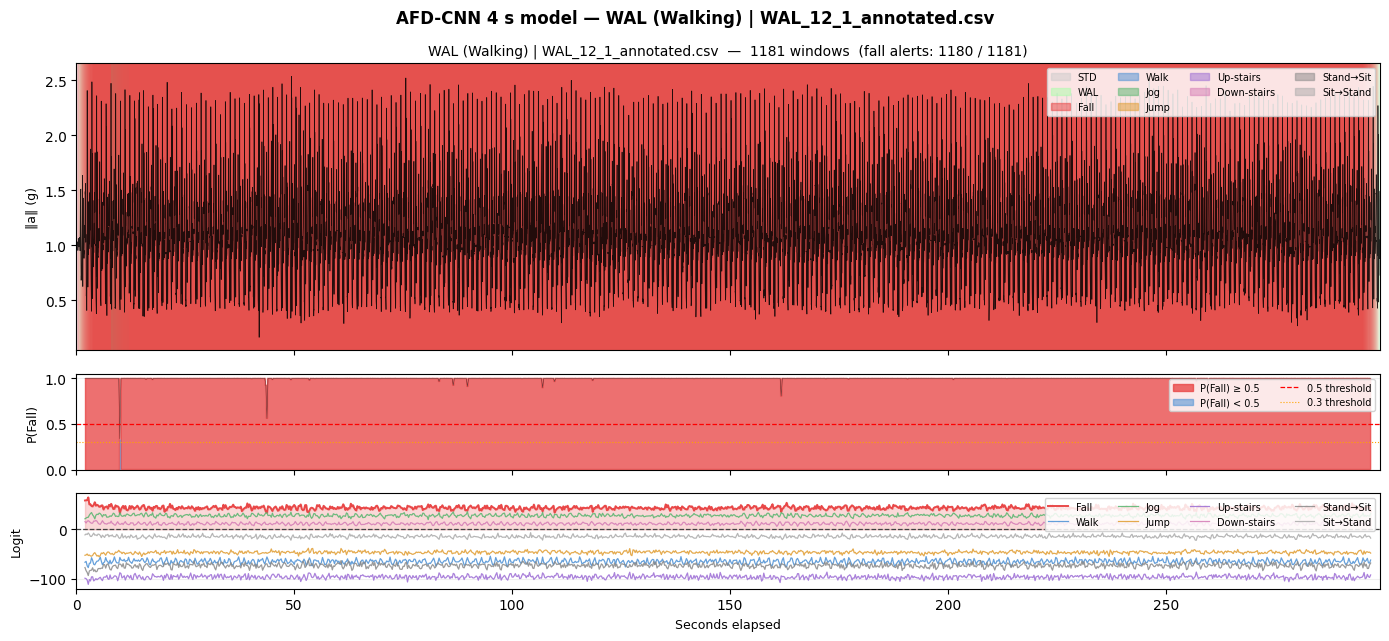

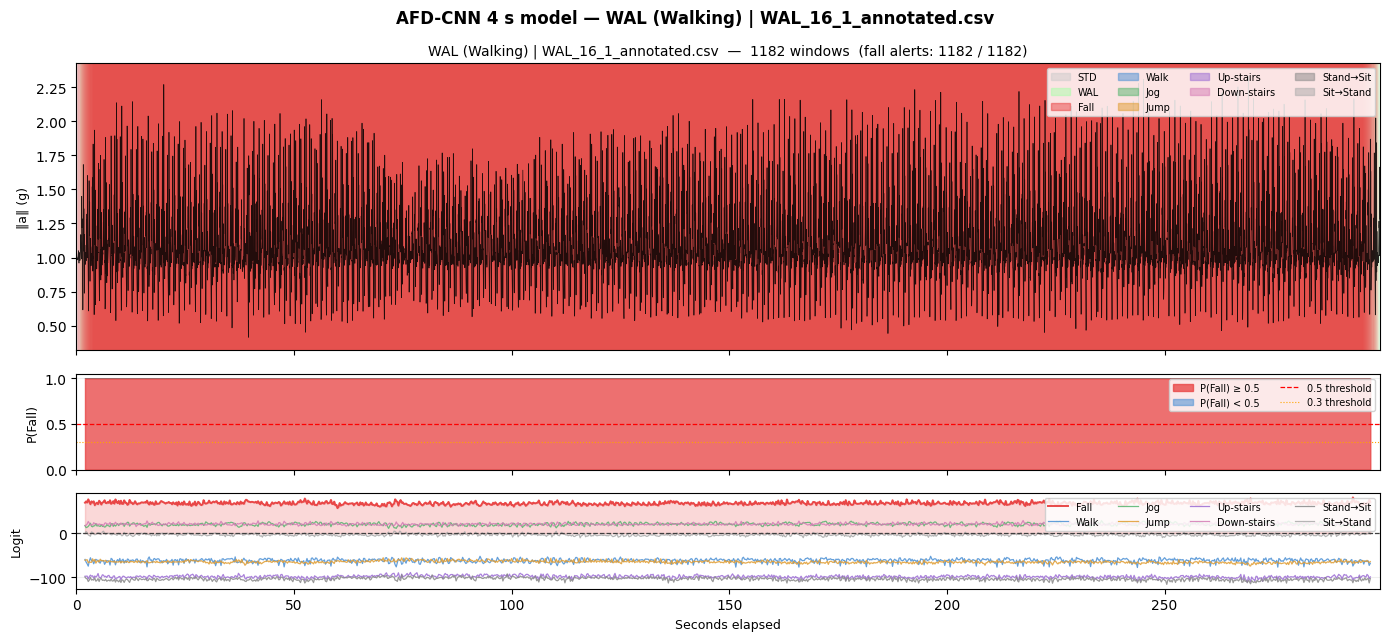

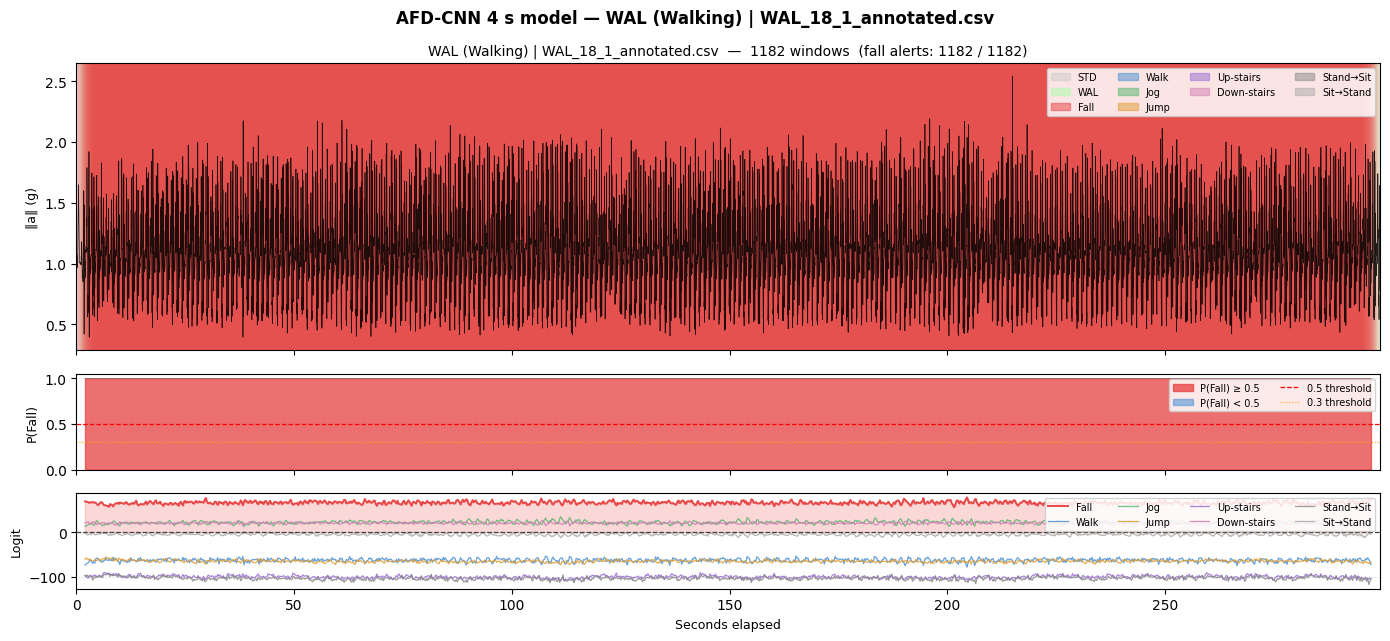

In [27]:
# ── Stage 4: per-recording plots ──────────────────────────────────────────
to_plot_walk = walk_records if MAX_WALK_FILES is None else walk_records[:MAX_WALK_FILES]
print(f'Plotting {len(to_plot_walk)} of {len(walk_records)} WAL recordings...')

for r in to_plot_walk:
    if len(r.get('probs', [])) == 0:
        continue
    plot_recording(
        r['arr_g'], r['labels'], r['offsets'],
        r['probs'], r['logits'],
        r['fname'], 'WAL (Walking)',
    )

### 5b. Zoom — 16 s Excerpt of One Walk Recording

Same 3-panel layout but the x-axis is locked to a 16-second window centred on the middle of the first walk recording.
Each overlapping 4 s inference window is visible as an individual contribution to the P(Fall) and logit traces.
Vertical grey dotted lines mark every window start; x-axis ticks every 1 s aid fine-grained timing.

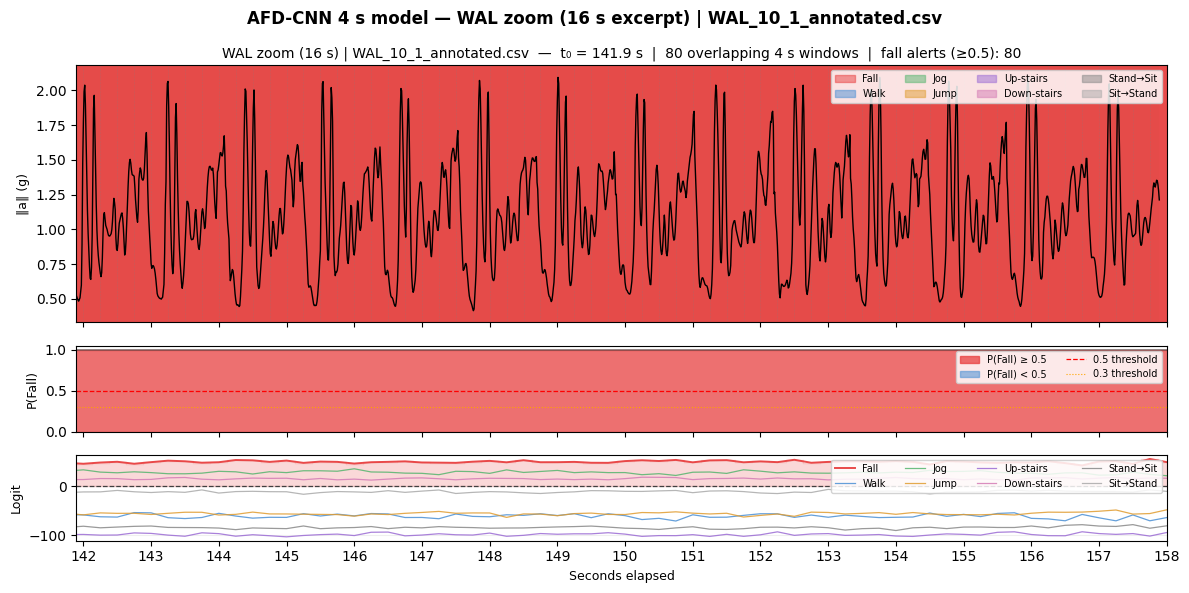

Zoom: 141.9–157.9 s  |  80 overlapping windows
P(Fall) in range: mean=1.000  max=1.000  alerts (≥0.5): 80/80


In [28]:
ZOOM_DUR_S = 16   # seconds to display

# Pick the first walk record that has inference results
r_zoom = next((r for r in walk_records if len(r.get('probs', [])) > 0), None)

if r_zoom is None:
    print('No walk records with inference results.')
else:
    n        = len(r_zoom['arr_g'])
    t_full   = np.arange(n) / FS_CNN
    mag_full = np.linalg.norm(r_zoom['arr_g'], axis=1)
    x_starts = r_zoom['offsets'] / FS_CNN
    x_ends   = x_starts + WIN_LEN / FS_CNN
    x_centers = (r_zoom['offsets'] + WIN_LEN / 2) / FS_CNN

    # Centre zoom on the middle of the recording
    t_mid   = t_full[-1] / 2
    t_start = max(0.0, t_mid - ZOOM_DUR_S / 2)
    t_end   = t_start + ZOOM_DUR_S

    # Windows that overlap the zoom range
    in_zoom    = (x_starts < t_end) & (x_ends > t_start)
    fall_prob  = r_zoom['probs'][in_zoom, FALL_IDX]
    fall_logit = r_zoom['logits'][in_zoom, FALL_IDX]
    logits_zoom = r_zoom['logits'][in_zoom]          # all 8 class logits
    pred_cls   = [CLASS_LIST[i] for i in np.argmax(r_zoom['probs'][in_zoom], axis=1)]
    xc_zoom    = x_centers[in_zoom]
    xs_zoom    = x_starts[in_zoom]

    # Signal samples inside the zoom range
    sig_mask = (t_full >= t_start) & (t_full <= t_end)
    t_zoom   = t_full[sig_mask]
    mag_zoom = mag_full[sig_mask]
    lab_zoom = r_zoom['labels'][sig_mask]

    fig, (ax_sig, ax_fall, ax_logit) = plt.subplots(
        3, 1, figsize=(12, 6), sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
    )

    # ── Signal panel ──────────────────────────────────────────────────────
    for lbl in dict.fromkeys(lab_zoom):
        mask    = lab_zoom == lbl
        changes = np.diff(mask.astype(np.int8), prepend=0, append=0)
        color   = PHASE_COLORS.get(lbl, '#eeeeee')
        for si, ei in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
            ax_sig.axvspan(t_zoom[si], t_zoom[min(ei, len(t_zoom) - 1)],
                           color=color, alpha=0.30, linewidth=0)

    bar_w = WIN_LEN / FS_CNN   # 4 s
    for xs, pc in zip(xs_zoom, pred_cls):
        ax_sig.axvspan(xs, xs + bar_w,
                       color=CLASS_COLORS.get(pc, '#cccccc'), alpha=0.15, linewidth=0)

    # Mark each window start so individual windows are visible
    for xs in xs_zoom:
        ax_sig.axvline(xs, color='grey', lw=0.4, ls=':', alpha=0.6)

    ax_sig.plot(t_zoom, mag_zoom, color='black', lw=1.0)
    ax_sig.set_ylabel('‖a‖ (g)', fontsize=9)
    ax_sig.set_title(
        f'WAL zoom ({ZOOM_DUR_S} s) | {r_zoom["fname"]}  —  '
        f't₀ = {t_start:.1f} s  |  '
        f'{len(fall_prob)} overlapping 4 s windows  |  '
        f'fall alerts (≥0.5): {(fall_prob >= 0.5).sum()}',
        fontsize=10,
    )
    class_patches = [mpatches.Patch(color=CLASS_COLORS[l], alpha=0.5,
                                    label=CLASS_NAMES[l]) for l in CLASS_LIST]
    ax_sig.legend(handles=class_patches, fontsize=7, loc='upper right',
                  ncol=4, framealpha=0.85)

    # ── P(Fall) panel ─────────────────────────────────────────────────────
    ax_fall.fill_between(xc_zoom, 0, fall_prob,
                         where=fall_prob >= 0.5,
                         color='#e84040', alpha=0.75, step='mid', label='P(Fall) ≥ 0.5')
    ax_fall.fill_between(xc_zoom, 0, fall_prob,
                         where=fall_prob < 0.5,
                         color='#4a8fd4', alpha=0.55, step='mid', label='P(Fall) < 0.5')
    ax_fall.plot(xc_zoom, fall_prob, color='#111111', lw=0.8, alpha=0.7)
    ax_fall.axhline(0.5, color='red',    ls='--', lw=0.9, label='0.5 threshold')
    ax_fall.axhline(0.3, color='orange', ls=':',  lw=0.8, label='0.3 threshold')
    ax_fall.set_ylim(0, 1.05)
    ax_fall.set_ylabel('P(Fall)', fontsize=9)
    ax_fall.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.85)
    ax_fall.grid(True, axis='y', alpha=0.2)

    # ── Activity logits panel ─────────────────────────────────────────────
    ax_logit.fill_between(xc_zoom, 0, fall_logit,
                          where=fall_logit >= 0,
                          color='#e84040', alpha=0.20, step='mid')
    ax_logit.fill_between(xc_zoom, 0, fall_logit,
                          where=fall_logit < 0,
                          color='#4a8fd4', alpha=0.15, step='mid')
    ax_logit.plot(xc_zoom, fall_logit,
                  color=CLASS_COLORS[0], lw=1.4, alpha=0.95, label='Fall')
    for cls_id, cls_name in LOGIT_OVERLAY:
        ax_logit.plot(xc_zoom, logits_zoom[:, CLASS_LIST.index(cls_id)],
                      color=CLASS_COLORS[cls_id], lw=0.9, alpha=0.85, label=cls_name)
    ax_logit.axhline(0, color='0.25', ls='--', lw=0.9)
    ax_logit.set_ylabel('Logit', fontsize=9)
    ax_logit.set_xlabel('Seconds elapsed', fontsize=9)
    ax_logit.legend(fontsize=7, loc='upper right', ncol=4, framealpha=0.85)
    ax_logit.grid(True, axis='y', alpha=0.2)

    ax_sig.set_xlim(t_start, t_end)
    ax_logit.set_xticks(np.arange(np.ceil(t_start), t_end + 0.5, 1.0))

    fig.suptitle(
        f'AFD-CNN 4 s model — WAL zoom ({ZOOM_DUR_S} s excerpt) | {r_zoom["fname"]}',
        fontsize=12, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

    print(f'Zoom: {t_start:.1f}–{t_end:.1f} s  |  {len(fall_prob)} overlapping windows')
    print(f'P(Fall) in range: mean={fall_prob.mean():.3f}  '
          f'max={fall_prob.max():.3f}  '
          f'alerts (≥0.5): {(fall_prob >= 0.5).sum()}/{len(fall_prob)}')

## 6. P(Fall) Distribution Comparison — Falls vs Walk

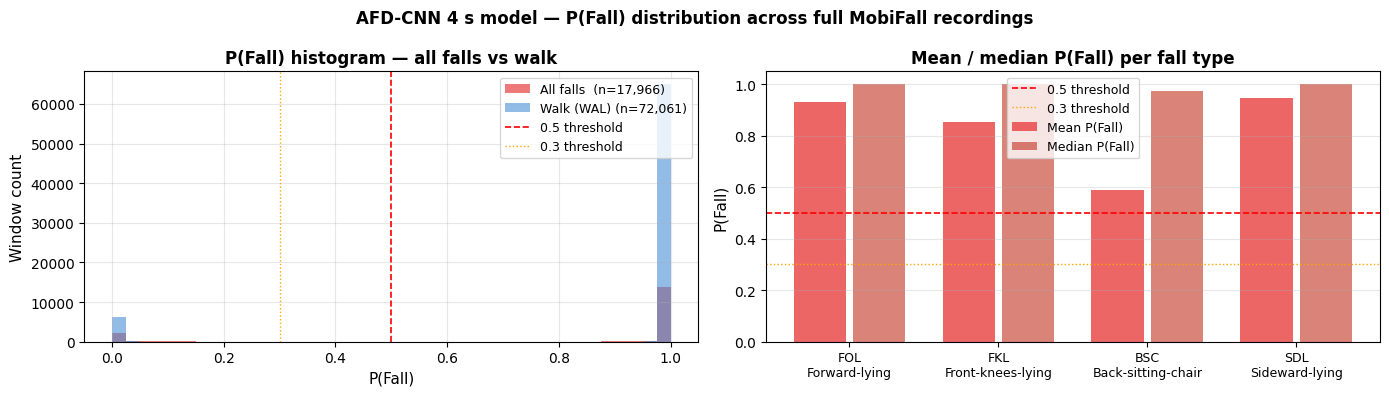

Falls   — mean P(Fall): 0.830  |  median: 1.000
Walk    — mean P(Fall): 0.907  |  median: 1.000

FOL  — mean: 0.930  median: 1.000  alert rate (≥0.5): 93.27%
FKL  — mean: 0.854  median: 1.000  alert rate (≥0.5): 85.69%
BSC  — mean: 0.591  median: 0.972  alert rate (≥0.5): 59.23%
SDL  — mean: 0.945  median: 1.000  alert rate (≥0.5): 94.76%


In [29]:
# Aggregate all P(Fall) values across all files
all_fall_fp  = np.concatenate([r['probs'][:, FALL_IDX]
                                for r in fall_records if len(r.get('probs', [])) > 0])
all_walk_fp  = np.concatenate([r['probs'][:, FALL_IDX]
                                for r in walk_records if len(r.get('probs', [])) > 0])

# Per fall-type P(Fall)
per_code_fp  = {code: np.concatenate(
    [r['probs'][:, FALL_IDX] for r in fall_records
     if r['code'] == code and len(r.get('probs', [])) > 0])
    for code in FALL_CODES}

bins = np.linspace(0, 1, 41)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: falls vs walk histogram
axes[0].hist(all_fall_fp, bins=bins, color='#e84040', alpha=0.70,
             label=f'All falls  (n={len(all_fall_fp):,})')
axes[0].hist(all_walk_fp, bins=bins, color='#4a8fd4', alpha=0.60,
             label=f'Walk (WAL) (n={len(all_walk_fp):,})')
axes[0].axvline(0.5, color='red',    ls='--', lw=1.2, label='0.5 threshold')
axes[0].axvline(0.3, color='orange', ls=':',  lw=1.0, label='0.3 threshold')
axes[0].set_xlabel('P(Fall)', fontsize=11)
axes[0].set_ylabel('Window count', fontsize=11)
axes[0].set_title('P(Fall) histogram \u2014 all falls vs walk', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: per fall type mean P(Fall)
means   = [per_code_fp[c].mean() for c in FALL_CODES]
medians = [np.median(per_code_fp[c]) for c in FALL_CODES]
xlabels = [f'{c}\n{FALL_DESCRIPTIONS[c]}' for c in FALL_CODES]

x = np.arange(len(FALL_CODES))
axes[1].bar(x - 0.2, means,   width=0.35, color='#e84040', alpha=0.80, label='Mean P(Fall)')
axes[1].bar(x + 0.2, medians, width=0.35, color='#c03020', alpha=0.60, label='Median P(Fall)')
axes[1].axhline(0.5, color='red',    ls='--', lw=1.2, label='0.5 threshold')
axes[1].axhline(0.3, color='orange', ls=':',  lw=1.0, label='0.3 threshold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('P(Fall)', fontsize=11)
axes[1].set_title('Mean / median P(Fall) per fall type', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('AFD-CNN 4 s model \u2014 P(Fall) distribution across full MobiFall recordings',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Falls   \u2014 mean P(Fall): {all_fall_fp.mean():.3f}  |  median: {np.median(all_fall_fp):.3f}')
print(f'Walk    \u2014 mean P(Fall): {all_walk_fp.mean():.3f}  |  median: {np.median(all_walk_fp):.3f}')
print()
for code in FALL_CODES:
    fp = per_code_fp[code]
    print(f'{code}  \u2014 mean: {fp.mean():.3f}  median: {np.median(fp):.3f}  '
          f'alert rate (\u22650.5): {(fp >= 0.5).mean():.2%}')

In [30]:
fd_sess.close()
print('TF session closed.')

TF session closed.
